In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import time
import datetime
import pandas as pd
from tqdm import tqdm
from matplotlib.colors import LinearSegmentedColormap, PowerNorm

import FORCE_module as FC
import LLE_PR_activities_module as md
import Data_Opening_Tools_module as DT


# Implementing the FORCE Learning Method for a Rate Based RNN

Link to Alessandro Ingrosso's tutorial: 
https://github.com/WouterKroot/ingrosso_rnn/blob/main/recurrent_force.ipynb from which I took inspiration.

# Steps to take:

RLS-FORCE is derived from the following cost function:

$$C = \sum^1_{k=0} \frac{1}{2}e^2_{(k)} = \sum^1_{k=0} \frac{1}{2}(f^{target}_{(k)} - (\vec{W}^{out})^T\vec{r}_{(k)})^2 + \frac{\alpha}{2}||\vec{W}^{out}||^2$$

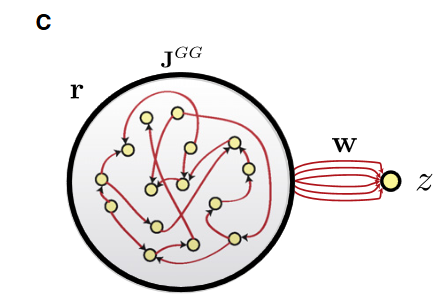

1. $z(t) = \vec{w}^T\vec{r}(t)$, readout unit $z(t)$ at time $t$, which is the weights coming from the network to the output neurons times the activation functions of the neurons in the network to the output. 

In first-order reduced and controlled error or FORCE learning you hold the feedback signal close to its desired value. Because the method requires tight control of a small (first-order) error. A learning algorithm that is suitable FORCE learning has to rapidly reduce the magnitude of the difference between the actual and desired output to a small value, and keep it small while searching for and eventually finding a set of fixed readout weights that can maintain a small error without further modification. 

2. $e_-(t) = \vec{w}^T(t-\Delta t)\vec{r}(t) - f(t)$, is the error between readout unit $z(t-\Delta t)$ and the target output $f(t)$ before the weight update or at the previous weight update (i.e. interval time $\Delta t$ the weight gets updated) the weight gets updated.
 
Then the error gets calculated again at time $t$ which is at the next weight update time interval $\Delta t$ (i.e. $t-\Delta t + \Delta t = t$)

3. $e_+(t) = \vec{w}(t)\vec{r}(t) - f(t)$

It needs to be the case that:

4. $|e_+(t)|<|e_-(t)|$, in order to let the system learn to become closer to the target output $f(t)$

Eventually over time we want to achieve that the $e_+(t)$ and $e_-(t)$ are the same, so that the learning can stop, i.e.:

5. $\frac{e_+(t)}{e_-(t)} \rightarrow 1$

FORCE learning is unusual in that the magnitudes of these errors are small throughout the learning process, although similarly reduced over time. This is done by making a large reduction in size at the time of the first weight update and then maintaining small error throughout the trianing while slowly decreasing over time. 

To do this they use the recursive least-squares (RLS) algorithm (could use different algorithms)

6. $\vec{w}(t) = \vec{w}(t - \Delta t) - e_-(t)\vec{P}(t)\vec{r}(t)$

7. 
with $\vec{P}(t)$ (a matrix with multiple learning rates) being a NxN matrix that is updated at the same time as the weights according to the rule:

8. $\vec{P}(t) = \vec{P}(t - \Delta t) -  \frac{\vec{P}(t- \Delta t) \vec{r}(t) \vec{r}^T(t) \vec{P}(t- \Delta t)}{1 + \vec{r}^T(t) \vec{P}(t- \Delta t) \vec{r}(t)}$

Which is initialized by the value:

9. $\vec{P}(0) = \frac{\vec{I}}{\alpha}$, with $\vec{I}$ being the identity matrix and $\alpha$ is a constant parameter.

$\vec{P}$ is a running estimate of the inverse of the correlation matrix of the network rates $\vec{r}$ plus a regularization terms:

10. $\vec{P} = (\sum_t \vec{r}(t)\vec{r}^T(t) + \alpha \vec{I})^{-1}$



## New Update Rules to Implement

1. for outgoing weights from J to z:
$$\mathbf{w}(t) = \mathbf{w}(t - \Delta t) -  \frac{\mathbf{P}(t) \mathbf{r}(t) e^T_-(t)}{1 + \mathbf{r}^T(t) \mathbf{P}(t- \Delta t) \mathbf{r}(t)}$$

2. Correlation matrix update stays the same
$$\mathbf{P}(t) = \mathbf{P}(t - \Delta t) -  \frac{\mathbf{P}(t- \Delta t) \mathbf{r}(t) \mathbf{r}^T(t) \mathbf{P}(t- \Delta t)}{1 + \mathbf{r}^T(t) \mathbf{P}(t- \Delta t) \mathbf{r}(t)}$$

3. Update rule for generator network or reservoir RNN connection matrix J: 
$$\mathbf{J}_{GG}(t) = \mathbf{J}_{GG}(t - \Delta t) - \frac{\mathbf{1}_{N \times M} e_-(t) \mathbf{r}^T(t) \mathbf{P}(t)}{1 + \mathbf{r}^T(t) \mathbf{P}(t- \Delta t) \mathbf{r}(t)}$$

3.1 Corrected version of update rule 3.:
$$\mathbf{J}_{GG}(t) = \mathbf{J}_{GG}(t - \Delta t) - \frac{\mathbf{P}(t) \mathbf{r}(t) e_-^T(t) \mathbf{1}_{M \times N}}{1 + \mathbf{r}^T(t) \mathbf{P}(t- \Delta t) \mathbf{r}(t)}$$


# FORCE trainer class

# Training and testing with eta = 1 and Dt = 0.2 

## For running big blocks for the heatmap

In [ ]:
# Fixed parameters according to Sussillo's code


# === Global plot style ===
plt.rcParams.update({
    'axes.titlesize': 64,
    'axes.labelsize': 56,        # x/y labels
    'xtick.labelsize': 48,       # x ticks
    'ytick.labelsize': 48,       # y ticks
    'legend.fontsize': 20,       # legend text
    'figure.titlesize': 32,      # suptitle (global title)
    'legend.title_fontsize': 28  # legend title
})




Dt = 0.2
eta = 1
dt = 0.1
alpha = 1.0
tau = 1.0
N = 1000
p = 1.0
learn_start = 0 ################CHECK########################
learn_start_idx = int(learn_start / dt)
initialisation_seed = np.array([0])

# Parameter ranges
# n_weight_seeds = range(1, 2)

#change n_sets for test
#n_seeds = 1 
n_weight_seeds = np.array([9])
# n_init_seeds = 0
# HSMs = np.arange(0, 5.2, 0.2)
# HSMs = np.arange(0, 0.4, 0.2)
#HSMs = np.arange(2.6, 4.2, 0.2)
# HSMs = np.array([0.000, 0.001, 0.002, ])
# #HSMs = np.arange(3.6, 4.6, 0.2)
# #HSMs = np.arange(4.6, 5.0, 0.2)
# #HSMs = np.array([0.0,0.2,0.4])

# #HSMs = np.arange(0.4, 1.6, 0.2)
# gains = np.array([1.2, 1.4, 1.6, 1.8, 2.0])
# #gains = np.arange(0, 10.2, 0.2)

# Grok_factor = 50


# tasks = list(product(gains, n_weight_seeds, HSMs))



#for working with tuples combinations of gains and HSMs
# gain_HSM_combos = [
#     (2, 0.013),
#     (2, 0.018),
#     (1.8, 0.007),
#     (1.8, 0.011),
#     (1.8, 0.015),
#     (1.6, 0.001),
#     (1.6, 0.005),
#     (1.6, 0.010),
#     (1.4, 0.000),
#     (1.4, 0.004),
#     (1.4, 0.005),
#     (1.2, 0.000),
#     (1.2, 0.001),
#     (1.2, 0.002),  
# ]

gain_HSM_combos = [
    # (2, 0.013),
    # (2, 0),
    # (1.6, 0),  
    # (1.6, 0.005),
    (1.4, 0.01),
    (1.4, 0.005),
]

tasks = [
    (gain, seed, HSM)
    for gain, HSM in gain_HSM_combos
    for seed in n_weight_seeds
]

# Storage for first-period test Rsquareds (across all configurations)
all_first_period_test_Rsquared = []
all_first_period_training_Rsquared = []

averages_training_Rsquared = []
averages_testing_Rsquared = []

# Process each task and save immediately
for task_idx, (gain, weights_seed, HSM) in enumerate(tasks):
    print(f"  gain={gain}, weights_seed={weights_seed}, HSM={HSM}")
    
    # Test best configuration
    start = time.time()


    trainer = FC.FORCETrainer(
        N=N,
        p=p,
        gain=gain,
        HSM=HSM,
        tau=tau,
        dt=dt,
        Dt=Dt,
        alpha=alpha,
        eta=eta,
        weights_seed=weights_seed,
        initialisation_seed=initialisation_seed
    )



    #Train
    train_time = 1440 + learn_start  #######################CHECK THIS############################
    running_time = np.arange(0, train_time, dt)
    target_train = FC.create_complex_target(running_time, dt)
    train_zs = trainer.train(target_train, running_time, learn_start, verbose=True)

    # Shift target for plotting
    # target_shifted = np.full_like(target_train, np.nan)
    # target_shifted[learn_start_idx:] = target_train[:-learn_start_idx]

    #Test
    after_training_time = 1440  # Can be changed to 4000, 6000, etc. #######################CHECK THIS############################
    test_time_arr = np.arange(0, after_training_time, dt)
    target_test = FC.create_complex_target(test_time_arr, dt, 1/60)
    test_zs = trainer.test(target_test, test_time_arr, verbose=True)

    # def FC.create_complex_target(running_time, dt, freq=1/60, amps=None):
    steps_per_period = 1200  # 20000 steps #######################CHECK THIS############################
    period_time = np.arange(learn_start, train_time, dt)


    # Rsquared during training (all periods)
    Rsquareds_train = []
    Rsquareds_time_train = []

    for idx in range(0, len(period_time), steps_per_period):
        time_per_period = running_time[idx:idx+steps_per_period]
        target_per_period = target_train[idx:idx+steps_per_period]
        z_per_period = train_zs['all_z_out'][idx:idx+steps_per_period]
        
        if len(z_per_period) == steps_per_period:
            end_time_step = time_per_period[-1]
            sum_SS_res = ((target_per_period - z_per_period)**2).sum() #sum of squares of residuals
            sum_SS_tot = ((target_per_period - np.average(target_per_period))**2).sum()#total sum of squares proportional to the variance of the data
            Rsquared = 1 - (sum_SS_res/sum_SS_tot)
            Rsquareds_train.append(Rsquared)
            Rsquareds_time_train.append(end_time_step)
            
    # Rsquared_average_training = np.mean(Rsquareds_train)
    # Extract ONLY the first period train Rsquared for saving
    if len(Rsquareds_train) > 0:
        Rsquared_first_period = Rsquareds_train[0]
        Rsquared_average_training = np.mean(Rsquareds_train)
        print(f"  First period train R^2: {Rsquared_first_period:.6f}")
        all_first_period_training_Rsquared.append(Rsquared_first_period)

        print(f"  Average train R^2: {Rsquared_average_training:.6f}")
        averages_training_Rsquared.append(Rsquared_average_training)
        
    else:
        print(f"  Warning: No complete periods in test data")
        Rsquared_average_training = np.nan
        averages_training_Rsquared.append(Rsquared_average_training)
        
        Rsquared_first_period = np.nan
        all_first_period_training_Rsquared.append(Rsquared_first_period)
       

    # Rsquared after training (ALL periods for plotting)
    Rsquareds_test = []
    Rsquareds_time_test = []

    for idx in range(0, len(test_time_arr), steps_per_period):
        time_per_period = test_time_arr[idx:idx+steps_per_period]
        target_per_period = target_test[idx:idx+steps_per_period]
        z_per_period = test_zs['z_out'][idx:idx+steps_per_period]
        
        if len(z_per_period) == steps_per_period:
            end_time_step = time_per_period[-1]
            sum_SS_res = ((target_per_period - z_per_period)**2).sum() #sum of squares of residuals
            sum_SS_tot = ((target_per_period - np.average(target_per_period))**2).sum()#total sum of squares proportional to the variance of the data
            Rsquared = 1 - (sum_SS_res/sum_SS_tot)
            Rsquareds_test.append(Rsquared)
            Rsquareds_time_test.append(end_time_step)

    
    # Extract ONLY the first period test Rsquared for saving
    if len(Rsquareds_test) > 0:
        Rsquared_first_period = Rsquareds_test[0]
        Rsquared_average_testing = np.mean(Rsquareds_test)
        print(f"  First period test R^2: {Rsquared_first_period:.6f}")
        all_first_period_test_Rsquared.append(Rsquared_first_period)
        print(f"  Average test R^2: {Rsquared_average_testing:.6f}")
        averages_testing_Rsquared.append(Rsquared_average_testing)

    else:
        print(f"  Warning: No complete periods in test data")
        Rsquared_average_testing = np.nan
        averages_testing_Rsquared.append(Rsquared_average_testing)
        
        Rsquared_first_period = np.nan
        all_first_period_test_Rsquared.append(Rsquared_first_period)



    #######################CHECK THIS FILE PATH############################
    filepath = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\Zoomed HSM 0-0.1 performance plots"
    os.makedirs(filepath, exist_ok=True)

    # filepath = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\test\tests"
    # os.makedirs(filepath, exist_ok=True)

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    
    filename = f"idx{task_idx:03d}_gain{gain:.1f}_HSM{HSM}_w_seed{weights_seed}_i_seed{initialisation_seed[0]}_{timestamp}.npz"
    full_path = os.path.join(filepath, filename)
    
    np.savez(
        full_path,
        J_initial=trainer.J_initial,
        w_out_initial=trainer.w_out_initial,
        J_trained=trainer.J_trained,
        w_out_trained=trainer.w_out_trained,
        z_out_training=train_zs['all_z_out'],
        z_out_test=test_zs['z_out'],
        running_time=running_time,
        test_time=test_time_arr,
        target_train=target_train,
        target_test=target_test,
        alpha=trainer.alpha,
        p=trainer.p,
        N=trainer.N,
        gain=gain,
        HSM=HSM,
        eta=eta,
        Dt=Dt,
        weights_seed=weights_seed,
    
        # Save ONLY first period test Rsquared
        first_period_test_Rsquared=Rsquared_first_period,
        # Also save all training Rsquareds (for all periods)
        Rsquareds_train=np.array(Rsquareds_train),
        Rsquareds_time_train=np.array(Rsquareds_time_train),
        # Save all test Rsquareds (for all periods) - for reference
        Rsquareds_test_all_periods=np.array(Rsquareds_test),
        Rsquareds_time_test_all_periods=np.array(Rsquareds_time_test),
        
        Rsquared_average_training = Rsquared_average_training,
        Rsquared_average_testing = Rsquared_average_testing
    )



    print(f"✓ Saved to: {filename}")

    # ############## Plotting training and testing trajectories
    # fig, axes = plt.subplots(4, 1, figsize=(12, 24))

    # # Training
    # # axes[0].plot(running_time, target_shifted, 'k--', linewidth=2, label='Target')
    # axes[0].plot(running_time, target_train, 'k--', linewidth=2, label='Target')
    # axes[0].plot(running_time, train_zs['all_z_out'], 'g', linewidth=2, label='RNN output')
    # axes[0].set_xlabel('Time (ms)')
    # axes[0].set_ylabel('Signal (A.U)')
    # #axes[0].set_title(f'Training: gain={gain:.1f}, HSM={HSM}, W_seed={weights_seed}, I_seed={initialisation_seed}')
    # #axes[0].legend(bbox_to_anchor = (1.10,1))
    # axes[0].grid(True, alpha=0.3)
    # # axes[0].set_xlim(0, learn_start)
    # # axes[0].set_ylim(-0.1, 0.1)

    # # Testing
    # axes[1].plot(test_time_arr, target_test, 'k--', linewidth=2, label='Target')
    # axes[1].plot(test_time_arr, test_zs['z_out'], 'r', linewidth=2, label='RNN output')
    # axes[1].set_xlabel('Time (ms)')
    # axes[1].set_ylabel('Signal (A.U)')
    # #axes[1].set_title(f'Testing (1st period R^2: {Rsquared_first_period:.6f})')
    # #axes[1].legend()
    # axes[1].grid(True, alpha=0.3)

    # #Rsquared during training plot (ALL periods)

    # axes[2].plot(Rsquareds_time_train, Rsquareds_train, 'b-', linewidth=2, label='R^2 per period')
    # axes[2].set_xlabel('Time (ms)')
    # axes[2].set_ylabel('R^2')
    # #axes[2].legend()
    # #axes[2].set_title(f'R^2 During Training: gain={gain:.1f}, HSM={HSM}')
    # axes[2].grid(True, alpha=0.3)



    # #Rsquared after training plot (ALL periods)

    # axes[3].plot(Rsquareds_time_test, Rsquareds_test, 'r-', linewidth=2, label='R^2 per period')
    # # Highlight the first period
    # if len(Rsquareds_test) > 0:
    #     axes[3].plot(Rsquareds_time_test[0], Rsquareds_test[0], 'go', markersize=10, 
    #             label=f'1st period: {Rsquared_first_period:.6f}')
    # axes[3].set_xlabel('Time (ms)')
    # axes[3].set_ylabel('R^2')
    # #axes[3].legend()
    # #axes[3].set_title(f'R^2 After Training: gain={gain:.1f}, HSM={HSM}')
    # axes[3].grid(True, alpha=0.3)

    # plt.tight_layout()

    fig, axes = plt.subplots(2, 2, figsize=(24, 16))

    # --- Top-left: Training trajectory ---
    ax = axes[0, 0]
    ax.plot(running_time, target_train, 'k--', linewidth=3, label='Target')
    ax.plot(running_time, train_zs['all_z_out'], 'g', linewidth=3, label='RNN output')
    ax.set_ylabel('Signal (A.U)')
    ax.tick_params(axis='x', labelbottom=False)
    ax.xaxis.label.set_visible(False)
    ax.grid(True, alpha=0.3)
    
    # --- Top-right: Testing trajectory ---
    ax = axes[0, 1]
    ax.plot(test_time_arr, target_test, 'k--', linewidth=3, label='Target')
    ax.plot(test_time_arr, test_zs['z_out'], 'r', linewidth=3, label='RNN output')
    ax.tick_params(axis='x', labelbottom=False)
    ax.tick_params(axis='y', labelleft=False)
    ax.xaxis.label.set_visible(False)
    ax.yaxis.label.set_visible(False)
    ax.grid(True, alpha=0.3)
    
    # --- Bottom-left: R² during training ---
    ax = axes[1, 0]
    ax.plot(Rsquareds_time_train, Rsquareds_train, 'g-', linewidth=3)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('R²')
    ax.grid(True, alpha=0.3)
    
    # --- Bottom-right: R² after training ---
    ax = axes[1, 1]
    ax.plot(Rsquareds_time_test, Rsquareds_test, 'r-', linewidth=3)
    if len(Rsquareds_test) > 0:
        ax.plot(Rsquareds_time_test[0], Rsquareds_test[0], 'go', markersize=10,
                label=f'1st period: {Rsquared_first_period:.6f}')
    ax.set_xlabel('Time (ms)')
    ax.tick_params(axis='y', labelleft=False)
    ax.yaxis.label.set_visible(False)
    ax.grid(True, alpha=0.3)

    # Match x-axis tick range across top row
    x_min_top = min(running_time[0], test_time_arr[0])
    x_max_top = max(running_time[-1], test_time_arr[-1])
    axes[0, 0].set_xlim(x_min_top, x_max_top)
    axes[0, 1].set_xlim(x_min_top, x_max_top)
    
    # Match x-axis tick range across bottom row
    x_min_bot = min(Rsquareds_time_train[0], Rsquareds_time_test[0])
    x_max_bot = max(Rsquareds_time_train[-1], Rsquareds_time_test[-1])
    axes[1, 0].set_xlim(x_min_bot, x_max_bot)
    axes[1, 1].set_xlim(x_min_bot, x_max_bot)
    
    # Fix y-axis to [0, 1] for bottom row
    axes[1, 0].set_ylim(0, 1.1)
    axes[1, 1].set_ylim(0, 1.1)
  
    plt.tight_layout()
    
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    Combined_plots_train_test_Rsquared_filename = f"gain{gain:.1f}_HSM{HSM}_W_seed{weights_seed}_time{timestamp}.png"
    #######################CHECK THIS FILE PATH############################
    Combined_plots_train_test_Rsquared_filepath = os.path.join(
    r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Performance plots thesis",
    Combined_plots_train_test_Rsquared_filename)

    # Combined_plots_train_test_Rsquared_filename = f"gain{gain:.1f}_HSM{HSM:.1f}_Dt{Dt:.1f}_eta{eta:.1f}_W_seed{weights_seed}_time{timestamp}.png"
    # #######################CHECK THIS FILE PATH############################
    # Combined_plots_train_test_Rsquared_filepath = os.path.join(
    # r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\test\tests",
    # Combined_plots_train_test_Rsquared_filename)

    
    plt.savefig(Combined_plots_train_test_Rsquared_filepath, dpi=300, bbox_inches='tight')



summary_filepath = os.path.join(
    r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Performance plots thesis\summary files zoomed in",
    f"first_period_test_R^2_summary_HSMs_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.npz")

# summary_filepath = os.path.join(
#     r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\test\tests",
#     f"first_period_test_Rsquared_summary_HSMs={HSMs}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.npz")

np.savez(
    summary_filepath,
    first_period_test_Rsquareds=np.array(all_first_period_test_Rsquared),
    gains=gains,
    HSMs=HSMs,
    etas=eta,
    Dts=Dt,
    weights_seeds= n_weight_seeds)



summary_first_period_training_filepath = os.path.join(
r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Performance plots thesis\summary files zoomed in",
f"first_period_training_R^2_summary_HSMs_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.npz")

# summary_first_period_training_filepath = os.path.join(
# r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\test\tests",
# f"first_period_training_Rsquared_summary_HSMs={HSMs}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.npz")


np.savez(
    summary_first_period_training_filepath,
    first_period_training_Rsquareds=np.array(all_first_period_training_Rsquared),
    gains=gains,
    HSMs=HSMs,
    etas=eta,
    Dts=Dt,
    weights_seeds= n_weight_seeds)



summary_averages_during_training_filepath = os.path.join(
r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Performance plots thesis\summary files zoomed in",
f"summary_averages_during_training_filepath_HSMs_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.npz")

# summary_averages_during_training_filepath = os.path.join(
# r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\test\tests",
# f"summary_averages_during_training_filepath_HSMs={HSMs}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.npz")

np.savez(
    summary_averages_during_training_filepath,
    averages_training_Rsquareds=np.array(averages_training_Rsquared),
    gains=gains,
    HSMs=HSMs,
    etas=eta,
    Dts=Dt,
    weights_seeds= n_weight_seeds)


summary_averages_after_training_filepath = os.path.join(
r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Performance plots thesis\summary files zoomed in",
f"summary_averages_after_training_filepath_HSMs_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.npz")

# summary_averages_after_training_filepath = os.path.join(
# r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\test\tests",
# f"summary_averages_after_training_filepath_HSMs={HSMs}_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.npz")


np.savez(
    summary_averages_after_training_filepath,
    averages_testing_Rsquareds=np.array(averages_testing_Rsquared),
    gains=gains,
    HSMs=HSMs,
    etas=eta,
    Dts=Dt,
    weights_seeds= n_weight_seeds)

print(f"Job complete")

## for testing individual cases

In [ ]:
import matplotlib.pyplot as plt

# Reset to avoid old notebook settings interfering
plt.rcdefaults()

# === Global plot style ===
plt.rcParams.update({
    'axes.titlesize': 32,
    'axes.labelsize': 28,        # x/y labels
    'xtick.labelsize': 24,       # x ticks
    'ytick.labelsize': 24,       # y ticks
    'legend.fontsize': 20,       # legend text
    'figure.titlesize': 32,      # suptitle (global title)
    'legend.title_fontsize': 28  # legend title
})

# Storage for first-period test Rsquareds (across all configurations)
all_first_period_test_Rsquared = []


dt = 0.1

learn_start = 0
learn_start_idx = int(learn_start / dt)


Dt = 0.2
eta = 1
# HSM = 0
# gain = 1.6
# HSMs = np.array([0.00, 0.01, 0.02])
# HSMs =  np.array([0.00, 0.04, 0.05])
HSMs = np.array([0.01, 0.05, 0.10])
# HSMs =  np.array([0.07, 0.11, 0.15])
# HSMs = np.array([0.13, 0.18])

# gains = np.array([1.2])
#gains = np.array([1.4])
gains = np.array([1.6])
# gains = np.array([1.8])
# gains = np.array([2.0])
dt = 0.1
alpha = 1.0
tau = 1.0
N = 1000
p = 1.0
weights_seed = 9
initialisation_seed = 1


# print(f"\n{'='*60}")
# print(f"  gain={gain}, HSM={HSM}, seed={weights_seed}")
# print(f"  eta={eta}, Dt={Dt}")
# print(f"{'='*60}")

for gain in gains:
    for HSM in HSMs: 
        # Create trainer with parameters from this configuration
        trainer = FC.FORCETrainer(
            N=N,
            p=p,
            gain=gain,
            HSM=HSM,
            tau=tau,
            dt=dt,
            Dt=Dt,
            alpha=alpha,
            eta=eta,
            weights_seed=weights_seed,
            initialisation_seed=initialisation_seed
        )
        
        
        
        #Train
        train_time = 1440 + learn_start  #######################CHECK THIS############################
        running_time = np.arange(0, train_time, dt)
        target_train = FC.create_complex_target(running_time, dt)
        train_zs = trainer.train(target_train, running_time, learn_start, verbose=True)
        
        # Shift target for plotting
        # target_shifted = np.full_like(target_train, np.nan)
        # target_shifted[learn_start_idx:] = target_train[:-learn_start_idx]
        
        #Test
        after_training_time = 1440  # Can be changed to 4000, 6000, etc. #######################CHECK THIS############################
        test_time_arr = np.arange(0, after_training_time, dt)
        target_test = FC.create_complex_target(test_time_arr, dt, 1/60)
        test_zs = trainer.test(target_test, test_time_arr, verbose=True)
        
        # def FC.create_complex_target(running_time, dt, freq=1/60, amps=None):
        steps_per_period = 1440  # 20000 steps #######################CHECK THIS############################
        time = np.arange(learn_start, train_time, dt)
        
        
        # Rsquared during training (all periods)
        Rsquareds_train = []
        Rsquareds_time_train = []
        
        for idx in range(0, len(time), steps_per_period):
            time_per_period = running_time[idx:idx+steps_per_period]
            target_per_period = target_train[idx:idx+steps_per_period]
            z_per_period = train_zs['all_z_out'][idx:idx+steps_per_period]
            
            if len(z_per_period) == steps_per_period:
                end_time_step = time_per_period[-1]
                sum_SS_res = ((target_per_period - z_per_period)**2).sum() #sum of squares of residuals
                sum_SS_tot = ((target_per_period - np.average(target_per_period))**2).sum()#total sum of squares proportional to the variance of the data
                Rsquared = 1 - (sum_SS_res/sum_SS_tot)
                Rsquareds_train.append(Rsquared)
                Rsquareds_time_train.append(end_time_step)
        
        # Rsquared after training (ALL periods for plotting)
        Rsquareds_test = []
        Rsquareds_time_test = []
        
        for idx in range(0, len(test_time_arr), steps_per_period):
            time_per_period = test_time_arr[idx:idx+steps_per_period]
            target_per_period = target_test[idx:idx+steps_per_period]
            z_per_period = test_zs['z_out'][idx:idx+steps_per_period]
            
            if len(z_per_period) == steps_per_period:
                end_time_step = time_per_period[-1]
                sum_SS_res = ((target_per_period - z_per_period)**2).sum() #sum of squares of residuals
                sum_SS_tot = ((target_per_period - np.average(target_per_period))**2).sum()#total sum of squares proportional to the variance of the data
                Rsquared = 1 - (sum_SS_res/sum_SS_tot)
                Rsquareds_test.append(Rsquared)
                Rsquareds_time_test.append(end_time_step)
        
        # Extract ONLY the first period test Rsquared for saving
        if len(Rsquareds_test) > 0:
            Rsquared_first_period = Rsquareds_test[0]
            print(f"  First period test Rsquared: {Rsquared_first_period:.6f}")
            all_first_period_test_Rsquared.append(Rsquared_first_period)
        else:
            print(f"  Warning: No complete periods in test data")
            Rsquared_first_period = np.nan
            all_first_period_test_Rsquared.append(Rsquared_first_period)
        
        
        
        ############## Plotting training and testing trajectories
        fig, axes = plt.subplots(4, 1, figsize=(12, 24))
        
        # Training
        # axes[0].plot(running_time, target_shifted, 'k--', linewidth=2, label='Target')
        axes[0].plot(running_time, target_train, 'k--', linewidth=2, label='Target')
        axes[0].plot(running_time, train_zs['all_z_out'], 'g', linewidth=2, label='RNN output')
        axes[0].set_xlabel('Time (ms)')
        axes[0].set_ylabel('Signal')
        axes[0].set_title(f'Training')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        # axes[0].set_xlim(0, learn_start)
        # axes[0].set_ylim(-0.00001, 0.00001)
        
        # Testing
        axes[1].plot(test_time_arr, target_test, 'k--', linewidth=2, label='Target')
        axes[1].plot(test_time_arr, test_zs['z_out'], 'r', linewidth=2, label='RNN output')
        axes[1].set_xlabel('Time (ms)')
        axes[1].set_ylabel('Signal')
        axes[1].set_title(f'Testing')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        #Rsquared during training plot (ALL periods)
        
        axes[2].plot(Rsquareds_time_train, Rsquareds_train, 'b-', linewidth=2, label='Rsquared per period')
        axes[2].set_xlabel('Time (ms)')
        axes[2].set_ylabel('Rsquared')
        axes[2].legend()
        axes[2].set_title(f'$R^2$ During Training')
        axes[2].grid(True, alpha=0.3)
        
        
        
        #Rsquared after training plot (ALL periods)
        
        axes[3].plot(Rsquareds_time_test, Rsquareds_test, 'r-', linewidth=2, label='Rsquared per period')
        # Highlight the first period
        if len(Rsquareds_test) > 0:
            axes[3].plot(Rsquareds_time_test[0], Rsquareds_test[0], 'go', markersize=10, 
                     label=f'1st period: {Rsquared_first_period:.3f}')
        axes[3].set_xlabel('Time (ms)')
        axes[3].set_ylabel('Rsquared')
        axes[3].legend()
        axes[3].set_title(f'$R^2$ After Training')
        axes[3].grid(True, alpha=0.3)
        
        # legend_kwargs = dict(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)
        # axes[0].legend(**legend_kwargs)
        # axes[1].legend(**legend_kwargs)
        # axes[2].legend(**legend_kwargs)
        # axes[3].legend(**legend_kwargs)
        
        plt.tight_layout()
        
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        
        Rsquared_test_filename = f"gain={gain}, HSM={HSM}, W_seed={weights_seed}, I_seed={initialisation_seed}, learnstart={learn_start} (η={eta:.3f}, Δt={Dt:.1f})_time{timestamp}.png"
        #######################CHECK THIS FILE PATH############################
        Rsquared_test_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Performance Plots thesis",
        Rsquared_test_filename
        )
        plt.savefig(Rsquared_test_filepath, dpi=300, bbox_inches='tight')
        
        plt.show()
        
        
        # Print summary statistics
        valid_Rsquareds = np.array([r for r in all_first_period_test_Rsquared if not np.isnan(r)])
        print(f"\nFirst Period Test Rsquared Summary:")
        print(f"  Mean: {np.mean(valid_Rsquareds):.6f}")
        print(f"  Std:  {np.std(valid_Rsquareds):.6f}")
        print(f"  Min:  {np.min(valid_Rsquareds):.6f} (best)")
        print(f"  Max:  {np.max(valid_Rsquareds):.6f} (worst)")

# For analysing with the optimized parameters from Threadripper 1

## loading in the data

In [ ]:
results = DT.load_combined_FORCE_results(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\gainHSM optimized params Dt and eta\FORCE_HSMs0_100randoms_periodic_1seed_W_and_Init")


In [17]:
Etas = results['Etas']
Dts = results['Dts']
Gains = results['Gains']
HSMs = results['HSMs']
Weights_Seeds = results['Weights_Seeds']
mean_maes = results['mean_maes']
std_maes = results['std_maes']

print(f"{Weights_Seeds}, shape weights_seed: {Weights_Seeds.shape}")
print(f"{Etas}, shape of etas: {Etas.shape}")
print(f" {Dts}, shape of Dts: {Dts.shape}")
print(f"{Gains}, shape of Gains: {Gains.shape}")
print(f"{mean_maes}, shape of mean_mae: {mean_maes.shape}")
print(f"{std_maes}, shape of std_mae: {std_maes.shape}")

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1], shape weights_seed: (19,)
[0.15152634 0.58759877 0.74809075 0.67127695 0.78985726 0.84972695
 0.28713216 0.86295372 0.84515519 0.35064672 0.56592217 0.81918504
 0.02857901 0.87676931 0.96535742 0.97565941 0.62599604 0.94107019
 0.77892074], shape of etas: (19,)
 [ 1.71142083 14.88788308 14.06940216 13.16563793 16.1874682   7.70158603
  1.81780188  7.75173942 13.67130228  9.7544513   2.5934897  14.81403438
  8.10121083  3.61263519  9.43321467  9.37577704  6.77017257  9.48872111
  8.28142492], shape of Dts: (19,)
[ 0.   0.5  1.   1.2  1.4  1.5  1.6  1.8  2.   2.5  3.   3.5  4.   5.
  6.   7.   8.   9.  10. ], shape of Gains: (19,)
[0.7530169  0.7530169  0.66088404 0.49452333 0.74016507 0.66118987
 0.92482803 0.70865012 0.87372281 0.91927192 0.87079769 0.84601441
 0.89762905 0.75179989 0.85584833 0.73802914 0.87875802 0.81900355
 0.82934485], shape of mean_mae: (19,)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.], shape of std_mae: (19,

In [19]:


# Quick check to verify data is aligned correctly
print("\nFirst 5 configurations:")
print(f"{'Idx':>3} {'Gain':>6} {'HSM':>6} {'eta':>8} {'Dt':>8} {'MAE':>10}")
print("-" * 50)
for i in range(min(5, len(Etas))):
    print(f"{i:3d} {Gains[i]:6.1f} {HSMs[i]:6.1f} {Etas[i]:8.4f} {Dts[i]:8.1f} {mean_maes[i]:10.6f}")

# This should output something like:
# ```
# Idx   Gain    HSM      eta       Dt        MAE
# --------------------------------------------------
#   0    0.2    0.2   0.6148    6.39   0.065596
#   1    0.2    1.0   0.1534   12.30   0.138166
#   2    0.2    2.0   0.4742    9.72   0.088316
#   3    0.2    3.0   0.7666   16.42   0.071626
#   4    0.2    4.0   0.2163   16.76   0.073360


First 5 configurations:
Idx   Gain    MSH      eta       Dt        MAE
--------------------------------------------------
  0    0.0    0.0   0.1515      1.7   0.753017
  1    0.5    0.0   0.5876     14.9   0.753017
  2    1.0    0.0   0.7481     14.1   0.660884
  3    1.2    0.0   0.6713     13.2   0.494523
  4    1.4    0.0   0.7899     16.2   0.740165


## Training and testing with the optimized parameters

In [21]:
#pre loop initialisations

plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['legend.title_fontsize'] = 14

print(f"Total number of configurations: {len(Etas)}")
print(f"Unique gains: {np.unique(Gains)}")
print(f"Unique HSMs: {np.unique(HSMs)}")

learn_start = 500##########################CHECK THIS################################
dt = 0.1
learn_start_idx = int(learn_start / dt)


####################CHECK THESE#########################
N=1000
p=1.0
tau=1.0
dt=0.1
Dt=0.2
alpha=1.0
initialisation_seed=1


Total number of configurations: 19
Unique gains: [ 0.   0.5  1.   1.2  1.4  1.5  1.6  1.8  2.   2.5  3.   3.5  4.   5.
  6.   7.   8.   9.  10. ]
Unique MSHs: [0.]


In [ ]:
# Test best configuration
start = time.time()

# Storage for first-period test Rsquareds (across all configurations)
all_first_period_test_Rsquared = []



# Loop over all entries (each entry is a unique gain/HSM/seed combination)
for i in range(len(Etas)):
    
    gain = Gains[i]
    HSM = HSMs[i]
    eta = Etas[i]
    #Dt = Dts[i]
    weights_seed = Weights_Seeds[i]
    mean_mae = mean_maes[i]
    std_mae = std_maes[i]
    
    print(f"\n{'='*60}")
    print(f"Processing configuration {i+1}/{len(Etas)}")
    print(f"  gain={gain:.1f}, HSM={HSM:.1f}, seed={weights_seed}")
    print(f"  eta={eta:.4f}, Dt={Dt:.1f}")
    print(f"  Expected MAE: {mean_mae:.6f}")
    print(f"{'='*60}")
    
    # Create trainer with parameters from this configuration
    trainer = FC.FORCETrainer(
        N=N,
        p=p,
        gain=gain,
        HSM=HSM,
        tau=tau,
        dt=dt,
        Dt=Dt,
        alpha=alpha,
        eta=eta,
        weights_seed=weights_seed,
        initialisation_seed=initialisation_seed
    )
    
    #Train
    train_time = 1440 + learn_start  #######################CHECK THIS############################
    running_time = np.arange(0, train_time, dt)
    target_train = FC.create_complex_target(running_time, dt)
    train_zs = trainer.train(target_train, running_time, verbose=True)
    
    # Shift target for plotting
    target_shifted = np.full_like(target_train, np.nan)
    target_shifted[learn_start_idx:] = target_train[:-learn_start_idx]
    
    #Test
    after_training_time = 1440  # Can be changed to 4000, 6000, etc. #######################CHECK THIS############################
    test_time_arr = np.arange(0, after_training_time, dt)
    target_test = FC.create_complex_target(test_time_arr, dt)
    test_zs = trainer.test(target_test, test_time_arr, verbose=True)
    
    # Rsquared calculations
    # freq = 1/60 #######################CHECK THIS############################
    # T_period = (1/freq) * 1000  # #######################CHECK THIS############################
    # steps_per_period = int(T_period / dt)  # 20000 steps

    steps_per_period = 1200  # 20000 steps #######################CHECK THIS############################
    Time = np.arange(learn_start, train_time, dt)
    
    
    # Rsquared during training (all periods)
    Rsquareds_train = []
    Rsquareds_time_train = []
    
    for idx in range(0, len(Time), steps_per_period):
        time_per_period = running_time[idx:idx+steps_per_period]
        target_per_period = target_train[idx:idx+steps_per_period]
        z_per_period = train_zs['all_z_out'][idx:idx+steps_per_period]
        
        if len(z_per_period) == steps_per_period:
            end_time_step = time_per_period[-1]
            sum_SS_res = ((target_per_period - z_per_period)**2).sum() #sum of squares of residuals
            sum_SS_tot = ((target_per_period - np.average(target_per_period))**2).sum()#total sum of squares proportional to the variance of the data
            Rsquared = 1 - (sum_SS_res/sum_SS_tot)
            Rsquareds_train.append(Rsquared)
            Rsquareds_time_train.append(end_time_step)
    
    # Rsquared after training (ALL periods for plotting)
    Rsquareds_test = []
    Rsquareds_time_test = []
    
    for idx in range(0, len(test_time_arr), steps_per_period):
        time_per_period = test_time_arr[idx:idx+steps_per_period]
        target_per_period = target_test[idx:idx+steps_per_period]
        z_per_period = test_zs['z_out'][idx:idx+steps_per_period]
        
        if len(z_per_period) == steps_per_period:
            end_time_step = time_per_period[-1]
            sum_SS_res = ((target_per_period - z_per_period)**2).sum() #sum of squares of residuals
            sum_SS_tot = ((target_per_period - np.average(target_per_period))**2).sum()#total sum of squares proportional to the variance of the data
            Rsquared = 1 - (sum_SS_res/sum_SS_tot)
            Rsquareds_test.append(Rsquared)
            Rsquareds_time_test.append(end_time_step)
    
    # Extract ONLY the first period test Rsquared for saving
    if len(Rsquareds_test) > 0:
        Rsquared_first_period = Rsquareds_test[0]
        print(f"  First period test R^2: {Rsquared_first_period:.6f}")
        all_first_period_test_Rsquared.append(Rsquared_first_period)
    else:
        print(f"  Warning: No complete periods in test data")
        Rsquared_first_period = np.nan
        all_first_period_test_Rsquared.append(Rsquared_first_period)
    
    #Saving it all
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    #######################CHECK THIS FILE PATH############################
    filepath = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\gainHSM zs vs sussillos target and Rsquareds during and after training"
    os.makedirs(filepath, exist_ok=True)
    
    filename = f"idx{i:03d}_gain{gain:.1f}_HSM{HSM:.1f}_eta{eta:.3f}_Dt{Dt:.1f}_{timestamp}.npz"
    full_path = os.path.join(filepath, filename)
    
    np.savez(
        full_path,
        J_initial=trainer.J_initial,
        w_out_initial=trainer.w_out_initial,
        J_trained=trainer.J_trained,
        w_out_trained=trainer.w_out_trained,
        z_out_training=train_zs['all_z_out'],
        z_out_test=test_zs['z_out'],
        running_time=running_time,
        test_time=test_time_arr,
        target_train=target_train,
        target_test=target_test,
        alpha=trainer.alpha,
        p=trainer.p,
        N=trainer.N,
        gain=gain,
        HSM=HSM,
        eta=eta,
        Dt=Dt,
        weights_seed=weights_seed,
        mean_test_mae=mean_mae,
        std_test_mae=std_mae,
        # Save ONLY first period test Rsquared
        first_period_test_Rsquared=Rsquared_first_period,
        # Also save all training Rsquareds (for all periods)
        Rsquareds_train=np.array(Rsquareds_train),
        Rsquareds_time_train=np.array(Rsquareds_time_train),
        # Save all test Rsquareds (for all periods) - for reference
        Rsquareds_test_all_periods=np.array(Rsquareds_test),
        Rsquareds_time_test_all_periods=np.array(Rsquareds_time_test)
    )
    
    print(f"✓ Saved to: {filename}")
    
    ############## Plotting training and testing trajectories
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Training
    axes[0].plot(running_time, target_shifted, 'k--', linewidth=2, label='Target')
    axes[0].plot(running_time, train_zs['all_z_out'], 'g', linewidth=2, label='RNN output')
    axes[0].set_xlabel('Time (ms)')
    axes[0].set_ylabel('Signal')
    axes[0].set_title(f'Training: gain={gain:.1f}, HSM={HSM:.1f} (η={eta:.3f}, Δt={Dt:.1f})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Testing
    axes[1].plot(test_time_arr, target_test, 'k--', linewidth=2, label='Target')
    axes[1].plot(test_time_arr, test_zs['z_out'], 'r', linewidth=2, label='RNN output')
    axes[1].set_xlabel('Time (ms)')
    axes[1].set_ylabel('Signal')
    axes[1].set_title(f'Testing (1st period Rsquared: {Rsquared_first_period:.6f})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    fig_filename = f"idx{i:03d}_trajectories_gain{gain:.1f}_HSM{HSM:.1f}_{timestamp}.png"
    #######################CHECK THIS FILE PATH############################
    fig_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM zs vs sussillos target during and after training",
        fig_filename
    )
    plt.savefig(fig_filepath, dpi=300, bbox_inches='tight')
    plt.close()
    
    #Rsquared during training plot (ALL periods)
    plt.figure(figsize=(10, 4))
    plt.plot(Rsquareds_time_train, Rsquareds_train, 'b-', linewidth=2, label='Rsquared per period')
    plt.xlabel('Time (ms)')
    plt.ylabel('Rsquared')
    plt.legend()
    plt.title(f'R^2 During Training: gain={gain:.1f}, HSM={HSM:.1f}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    Rsquared_train_filename = f"idx{i:03d}_R^2_train_gain{gain:.1f}_HSM{HSM:.1f}_{timestamp}.png"
    #######################CHECK THIS FILE PATH############################
    Rsquared_train_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM Rsquared sussillos target during training",
        Rsquared_train_filename
    )
    plt.savefig(Rsquared_train_filepath, dpi=300, bbox_inches='tight')
    plt.close()
    
    #Rsquared after training plot (ALL periods)
    plt.figure(figsize=(10, 4))
    plt.plot(Rsquareds_time_test, Rsquareds_test, 'r-', linewidth=2, label='Rsquared per period')
    # Highlight the first period
    if len(Rsquareds_test) > 0:
        plt.plot(Rsquareds_time_test[0], Rsquareds_test[0], 'go', markersize=10, 
                 label=f'1st period: {Rsquared_first_period:.6f}')
    plt.xlabel('Time (ms)')
    plt.ylabel('Rsquared')
    plt.legend()
    plt.title(f'Rsquared After Training: gain={gain:.1f}, HSM={HSM:.1f}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    Rsquared_test_filename = f"idx{i:03d}_R^2_test_gain{gain:.1f}_HSM{HSM:.1f}_{timestamp}.png"
    #######################CHECK THIS FILE PATH############################
    Rsquared_test_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM Rsquared sussillos target after training",
        Rsquared_test_filename
    )
    plt.savefig(Rsquared_test_filepath, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✓ Completed configuration {i+1}/{len(Etas)}")

end = time.time()
print(f"\nTotal duration: {end - start:.3f} seconds")
print(f"Processed {len(Etas)} configurations")

# Save summary of all first-period test Rsquareds
#######################CHECK THIS FILE PATH############################
summary_filepath = os.path.join(
    r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\gainHSM first period Rsquard sussillos target after training",
    f"first_period_test_Rsquared_summary_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.npz"
)

np.savez(
    summary_filepath,
    first_period_test_Rsquareds=np.array(all_first_period_test_Rsquared),
    gains=Gains,
    HSMs=HSMs,
    etas=Etas,
    Dts=Dts,
    weights_seeds=Weights_Seeds
)

print(f"\n✓ Saved summary of all first-period test Rsquareds to: {summary_filepath}")

# Print summary statistics
valid_Rsquareds = np.array([r for r in all_first_period_test_Rsquared if not np.isnan(r)])
print(f"\nFirst Period Test Rsquared Summary:")
print(f"  Mean: {np.mean(valid_Rsquareds):.6f}")
print(f"  Std:  {np.std(valid_Rsquareds):.6f}")
print(f"  Min:  {np.min(valid_Rsquareds):.6f} (best)")
print(f"  Max:  {np.max(valid_Rsquareds):.6f} (worst)")

In [ ]:
# Test best configuration
start = time.time()

# Storage for first-period test RMSEs (across all configurations)
all_first_period_test_rmse = []



# Loop over all entries (each entry is a unique gain/HSM/seed combination)
for i in range(len(Etas)):
    
    gain = Gains[i]
    HSM = HSMs[i]
    eta = Etas[i]
    #Dt = Dts[i]
    weights_seed = Weights_Seeds[i]
    mean_mae = mean_maes[i]
    std_mae = std_maes[i]
    
    print(f"\n{'='*60}")
    print(f"Processing configuration {i+1}/{len(Etas)}")
    print(f"  gain={gain:.1f}, HSM={HSM:.1f}, seed={weights_seed}")
    print(f"  eta={eta:.4f}, Dt={Dt:.1f}")
    print(f"  Expected MAE: {mean_mae:.6f}")
    print(f"{'='*60}")
    
    # Create trainer with parameters from this configuration
    trainer = FC.FORCETrainer(
        N=N,
        p=p,
        gain=gain,
        HSM=HSM,
        tau=tau,
        dt=dt,
        Dt=Dt,
        alpha=alpha,
        eta=eta,
        weights_seed=weights_seed,
        initialisation_seed=initialisation_seed
    )
    
    #Train
    train_time = 1440 + learn_start  #######################CHECK THIS############################
    running_time = np.arange(0, train_time, dt)
    target_train = FC.create_complex_target(running_time, dt)
    train_zs = trainer.train(target_train, running_time, verbose=True)
    
    # Shift target for plotting
    target_shifted = np.full_like(target_train, np.nan)
    target_shifted[learn_start_idx:] = target_train[:-learn_start_idx]
    
    #Test
    after_training_time = 1440  # Can be changed to 4000, 6000, etc. #######################CHECK THIS############################
    test_time_arr = np.arange(0, after_training_time, dt)
    target_test = FC.create_complex_target(test_time_arr, dt)
    test_zs = trainer.test(target_test, test_time_arr, verbose=True)
    
    # RMSE calculations
    freq = 1/60 #######################CHECK THIS############################
    T_period = (1/freq) * 1000  # #######################CHECK THIS############################
    steps_per_period = int(T_period / dt)  # 20000 steps
    
    # RMSE during training (all periods)
    RMSEs_train = []
    RMSEs_time_train = []
    
    for idx in range(0, len(running_time), steps_per_period):
        time_per_period = running_time[idx:idx+steps_per_period]
        target_per_period = target_train[idx:idx+steps_per_period]
        z_per_period = train_zs['all_z_out'][idx:idx+steps_per_period]
        
        if len(z_per_period) == steps_per_period:
            end_time_step = time_per_period[-1]
            sum_SE = ((target_per_period - z_per_period)**2).sum()
            RMSE = np.sqrt(sum_SE / steps_per_period)
            RMSEs_train.append(RMSE)
            RMSEs_time_train.append(end_time_step)
    
    # RMSE after training (ALL periods for plotting)
    RMSEs_test = []
    RMSEs_time_test = []
    
    for idx in range(0, len(test_time_arr), steps_per_period):
        time_per_period = test_time_arr[idx:idx+steps_per_period]
        target_per_period = target_test[idx:idx+steps_per_period]
        z_per_period = test_zs['z_out'][idx:idx+steps_per_period]
        
        if len(z_per_period) == steps_per_period:
            end_time_step = time_per_period[-1]
            sum_SE = ((target_per_period - z_per_period)**2).sum()
            RMSE = np.sqrt(sum_SE / steps_per_period)
            RMSEs_test.append(RMSE)
            RMSEs_time_test.append(end_time_step)
    
    # Extract ONLY the first period test RMSE for saving
    if len(RMSEs_test) > 0:
        RMSE_first_period = RMSEs_test[0]
        print(f"  First period test RMSE: {RMSE_first_period:.6f}")
        all_first_period_test_rmse.append(RMSE_first_period)
    else:
        print(f"  Warning: No complete periods in test data")
        RMSE_first_period = np.nan
        all_first_period_test_rmse.append(RMSE_first_period)
    
    #Saving it all
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    #######################CHECK THIS FILE PATH############################
    filepath = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\gainHSM zs vs sussillos target and RMSEs during and after training"
    os.makedirs(filepath, exist_ok=True)
    
    filename = f"idx{i:03d}_gain{gain:.1f}_HSM{HSM:.1f}_eta{eta:.3f}_Dt{Dt:.1f}_{timestamp}.npz"
    full_path = os.path.join(filepath, filename)
    
    np.savez(
        full_path,
        J_initial=trainer.J_initial,
        w_out_initial=trainer.w_out_initial,
        J_trained=trainer.J_trained,
        w_out_trained=trainer.w_out_trained,
        z_out_training=train_zs['all_z_out'],
        z_out_test=test_zs['z_out'],
        running_time=running_time,
        test_time=test_time_arr,
        target_train=target_train,
        target_test=target_test,
        alpha=trainer.alpha,
        p=trainer.p,
        N=trainer.N,
        gain=gain,
        HSM=HSM,
        eta=eta,
        Dt=Dt,
        weights_seed=weights_seed,
        mean_test_mae=mean_mae,
        std_test_mae=std_mae,
        # Save ONLY first period test RMSE
        first_period_test_rmse=RMSE_first_period,
        # Also save all training RMSEs (for all periods)
        RMSEs_train=np.array(RMSEs_train),
        RMSEs_time_train=np.array(RMSEs_time_train),
        # Save all test RMSEs (for all periods) - for reference
        RMSEs_test_all_periods=np.array(RMSEs_test),
        RMSEs_time_test_all_periods=np.array(RMSEs_time_test)
    )
    
    print(f"✓ Saved to: {filename}")
    
    ############## Plotting training and testing trajectories
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Training
    axes[0].plot(running_time, target_shifted, 'k-', linewidth=2, label='Target')
    axes[0].plot(running_time, train_zs['all_z_out'], 'g--', linewidth=2, label='RNN output')
    axes[0].set_xlabel('Time (ms)')
    axes[0].set_ylabel('Signal')
    axes[0].set_title(f'Training: gain={gain:.1f}, HSM={HSM:.1f} (η={eta:.3f}, Δt={Dt:.1f})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Testing
    axes[1].plot(test_time_arr, target_test, 'k-', linewidth=2, label='Target')
    axes[1].plot(test_time_arr, test_zs['z_out'], 'r--', linewidth=2, label='RNN output')
    axes[1].set_xlabel('Time (ms)')
    axes[1].set_ylabel('Signal')
    axes[1].set_title(f'Testing (1st period RMSE: {RMSE_first_period:.6f})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    fig_filename = f"idx{i:03d}_trajectories_gain{gain:.1f}_HSM{HSM:.1f}_{timestamp}.png"
    #######################CHECK THIS FILE PATH############################
    fig_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM zs vs sussillos target during and after training",
        fig_filename
    )
    plt.savefig(fig_filepath, dpi=300, bbox_inches='tight')
    plt.close()
    
    #RMSE during training plot (ALL periods)
    plt.figure(figsize=(10, 4))
    plt.plot(RMSEs_time_train, RMSEs_train, 'b-', linewidth=2, label='RMSE per period')
    plt.xlabel('Time (ms)')
    plt.ylabel('RMSE')
    plt.legend()
    plt.title(f'RMSE During Training: gain={gain:.1f}, HSM={HSM:.1f}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    rmse_train_filename = f"idx{i:03d}_RMSE_train_gain{gain:.1f}_HSM{HSM:.1f}_{timestamp}.png"
    #######################CHECK THIS FILE PATH############################
    rmse_train_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM Rsquared sussillos target during training",
        rmse_train_filename
    )
    plt.savefig(rmse_train_filepath, dpi=300, bbox_inches='tight')
    plt.close()
    
    #RMSE after training plot (ALL periods)
    plt.figure(figsize=(10, 4))
    plt.plot(RMSEs_time_test, RMSEs_test, 'r-', linewidth=2, label='RMSE per period')
    # Highlight the first period
    if len(RMSEs_test) > 0:
        plt.plot(RMSEs_time_test[0], RMSEs_test[0], 'go', markersize=10, 
                 label=f'1st period: {RMSE_first_period:.6f}')
    plt.xlabel('Time (ms)')
    plt.ylabel('RMSE')
    plt.legend()
    plt.title(f'RMSE After Training: gain={gain:.1f}, HSM={HSM:.1f}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    rmse_test_filename = f"idx{i:03d}_RMSE_test_gain{gain:.1f}_HSM{HSM:.1f}_{timestamp}.png"
    #######################CHECK THIS FILE PATH############################
    rmse_test_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM Rsquared sussillos target after training",
        rmse_test_filename
    )
    plt.savefig(rmse_test_filepath, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✓ Completed configuration {i+1}/{len(Etas)}")

end = time.time()
print(f"\nTotal duration: {end - start:.3f} seconds")
print(f"Processed {len(Etas)} configurations")

# Save summary of all first-period test RMSEs
#######################CHECK THIS FILE PATH############################
summary_filepath = os.path.join(
    r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\gainHSM first period Rsquard sussillos target after training",
    f"first_period_test_rmse_summary_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.npz"
)

np.savez(
    summary_filepath,
    first_period_test_rmses=np.array(all_first_period_test_rmse),
    gains=Gains,
    HSMs=HSMs,
    etas=Etas,
    Dts=Dts,
    weights_seeds=Weights_Seeds
)

print(f"\n✓ Saved summary of all first-period test RMSEs to: {summary_filepath}")

# Print summary statistics
valid_rmses = np.array([r for r in all_first_period_test_rmse if not np.isnan(r)])
print(f"\nFirst Period Test RMSE Summary:")
print(f"  Mean: {np.mean(valid_rmses):.6f}")
print(f"  Std:  {np.std(valid_rmses):.6f}")
print(f"  Min:  {np.min(valid_rmses):.6f} (best)")
print(f"  Max:  {np.max(valid_rmses):.6f} (worst)")

# Heatmap performance

## For normal loading of data and merging

In [ ]:

# ============================================================================
# FOR MERGING MULTIPLE SUMMARY FILES
# ============================================================================

foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\Summary files VScode\summaries_averages"

#foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\Summary files VScode\First period testing"

output_path = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\Summary files VScode\merged files"


#filename= "first_period_test_Rsquared_summary_*.npz"

# filename = "summary_averages_during_training_filepath_*.npz"

filename = "summary_averages_after_training_filepath_*.npz"

# name_Rsquareds_type = 'first_period_training_Rsquareds'
#name_Rsquareds_type = 'first_period_test_Rsquareds'
# name_Rsquareds_type = 'summary_averages_during_training'
#name_Rsquareds_type = 'averages_training_Rsquareds'

name_Rsquareds_type = 'averages_testing_Rsquareds'

# Merge files first
merged_filepath = DT.merge_summary_files(foldername, filename, name_Rsquareds_type, output_path)

# Then use the merged file for your heatmap
filepath = merged_filepath
summary = np.load(filepath)
# ... rest of your heatmap code

# Extract data
Rsquareds = summary[name_Rsquareds_type]
gains = summary['gains']
HSMs = summary['HSMs']
etas = summary['etas']
Dts = summary['Dts']
weights_seeds = summary['weights_seeds']

print(f"Loaded {len(Rsquareds)} configurations")
print(f"Gains: {np.unique(gains)}")
print(f"HSMs: {np.unique(HSMs)}")

In [28]:
# ============================================================================
# LOAD A SINGLE SUMMARY FILE
# ============================================================================

#loading first period test RMSEs per gain and HSM


# foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\Summary files VScode"
# filepath = os.path.join(foldername, "first_period_test_Rsquared_summary_HSMs=[0.4 0.6 0.8 1.  1.2 1.4 1.6]_20260203_095103.npz")

foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\ALL trials performance plot intended W matrix and HSM\VS_Code_FORCE_Gains_HSMs_periodic_W_5-9_and_Init_0-3"
filepath = os.path.join(foldername, "FORCE_combined_sorted_20260226_085902.npz")


# Load a specific configuration
# data = np.load('idx000_gain0.2_HSM0.2_eta0.615_Dt6.39_20260125_143025.npz')
# first_period_rmse = float(data['first_period_test_rmse'])
# print(f"First period test RMSE: {first_period_rmse:.6f}")

# Load summary
summary = np.load(filepath)

# Extract data
#Rsquareds_training = summary['first_period_training_Rsquared']
Rsquareds = summary['first_period_test_Rsquared']
gains = summary['gains']
HSMs = summary['HSMs']
#etas = summary['etas']
#Dts = summary['Dts']
weights_seeds = summary['weight_seeds']
init_seeds = summary['init_seeds']


print(f"Loaded {len(Rsquareds)} configurations")
print(f"Gains: {np.unique(gains)}")
print(f"HSMs: {np.unique(HSMs)}")

gains_expanded = []
HSMs_expanded = []
weights_seeds_expanded = []

for gain in gains:
    for weight_seed in weights_seeds:
        for HSM in HSMs:
            gains_expanded.append(gain)
            weights_seeds_expanded.append(weight_seed)
            HSMs_expanded.append(HSM)

# Convert to numpy arrays
gains = np.array(gains_expanded)
HSMs = np.array(HSMs_expanded)
weights_seeds = np.array(weights_seeds_expanded)

# Verify lengths match
print(f"gains_expanded: {len(gains)}")
print(f"HSMs_expanded: {len(HSMs)}")
print(f"weights_seeds_expanded: {len(weights_seeds)}")
print(f"Rsquareds: {len(Rsquareds)}")



Loaded 26520 configurations
Gains: [ 0.   0.2  0.4  0.6  0.8  1.   1.2  1.4  1.6  1.8  2.   2.2  2.4  2.6
  2.8  3.   3.2  3.4  3.6  3.8  4.   4.2  4.4  4.6  4.8  5.   5.2  5.4
  5.6  5.8  6.   6.2  6.4  6.6  6.8  7.   7.2  7.4  7.6  7.8  8.   8.2
  8.4  8.6  8.8  9.   9.2  9.4  9.6  9.8 10. ]
MSHs: [0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4
 3.6 3.8 4.  4.2 4.4 4.6 4.8 5. ]


KeyboardInterrupt: 

In [7]:
# ============================================================================
# LOADING SUMMARY FILE OF VSCODE WORKSPACE RUN
# ============================================================================

#loading first period test RMSEs per gain and HSM

# foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\ALL trials zoomed in HSM 0-0.1\VS_Code_FORCE_Gains_1-3_HSMs_0-0.1_periodic_W_5-9_and_Init_0-3"
# filepath = os.path.join(foldername, "FORCE_combined_sorted_20260308_135055.npz")

foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\ALL trials performance plot intended W matrix and HSM\VS_Code_FORCE_Gains_HSMs_periodic_W_5-9_and_Init_0-3"
filepath = os.path.join(foldername, "FORCE_combined_sorted_20260226_085902.npz")



# Load a specific configuration
# data = np.load('idx000_gain0.2_HSM0.2_eta0.615_Dt6.39_20260125_143025.npz')
# first_period_rmse = float(data['first_period_test_rmse'])
# print(f"First period test RMSE: {first_period_rmse:.6f}")

# Load summary
summary = np.load(filepath)

# Extract data
#Rsquareds_training = summary['first_period_training_Rsquared']
Rsquareds = summary['first_period_test_Rsquared']
gains = summary['gains']
HSMs = summary['HSMs']
#etas = summary['etas']
#Dts = summary['Dts']
weights_seeds = summary['weight_seeds']
init_seeds = summary['init_seeds']


print(f"Loaded {len(Rsquareds)} configurations")
print(f"Gains: {np.unique(gains)}")
print(f"HSMs: {np.unique(HSMs)}")

print(len(np.unique(gains)))
print(len(np.unique(HSMs)))

# Verify lengths match
print(f"gains_expanded: {len(gains)}")
print(f"HSMs_expanded: {len(HSMs)}")

print(f"weights_seeds_expanded: {len(weights_seeds)}")
print(f"Rsquareds: {len(Rsquareds)}")

#print(gains[0:1000])
# print(HSMs[0:1000])
# print(weights_seeds[0:1000])
# print(init_seeds[0:1000])

Loaded 26520 configurations
Gains: [ 0.   0.2  0.4  0.6  0.8  1.   1.2  1.4  1.6  1.8  2.   2.2  2.4  2.6
  2.8  3.   3.2  3.4  3.6  3.8  4.   4.2  4.4  4.6  4.8  5.   5.2  5.4
  5.6  5.8  6.   6.2  6.4  6.6  6.8  7.   7.2  7.4  7.6  7.8  8.   8.2
  8.4  8.6  8.8  9.   9.2  9.4  9.6  9.8 10. ]
MSHs: [0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4
 3.6 3.8 4.  4.2 4.4 4.6 4.8 5. ]
51
26
gains_expanded: 26520
MSHs_expanded: 26520
weights_seeds_expanded: 26520
Rsquareds: 26520


# For Single File Download


In [101]:
foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\MPI4py for TR1\3FORCE_Gains_HSMs_100randoms_periodic_W_5-9_and_Init_1-5"
filepath = os.path.join(foldername, "FORCE_combined_sorted_20260207_155857.npz")


# Load a specific configuration
# data = np.load('idx000_gain0.2_HSM0.2_eta0.615_Dt6.39_20260125_143025.npz')
# first_period_rmse = float(data['first_period_test_rmse'])
# print(f"First period test RMSE: {first_period_rmse:.6f}")

# Load summary
summary = np.load(filepath)

# Extract data
#Rsquareds_training = summary['first_period_training_Rsquared']
Rsquareds = summary['first_period_test_Rsquared']
averages_Rsquareds_train = summary['average_train_Rsquared']
gains = summary['gains']
HSMs = summary['HSMs']
#etas = summary['etas']
#Dts = summary['Dts']
weights_seeds = summary['weight_seeds']
init_seeds = summary['init_seeds']

In [103]:
print(f"gains_expanded: {gains}")
print(f"HSMs_expanded: {HSMs}")
print(f"weights_seeds_expanded: {weights_seeds}")
print(f"Rsquareds: {Rsquareds}")
print(f"average_Rsquared_train: {averages_Rsquareds_train}")

gains_expanded: [1.4]
MSHs_expanded: [0.]
weights_seeds_expanded: [5]
Rsquareds: [0.99987494]
average_Rsquared_train: [0.99983855]


# Heatmap for FORCE Performance

0.9999882090548944 -35.33520842956015


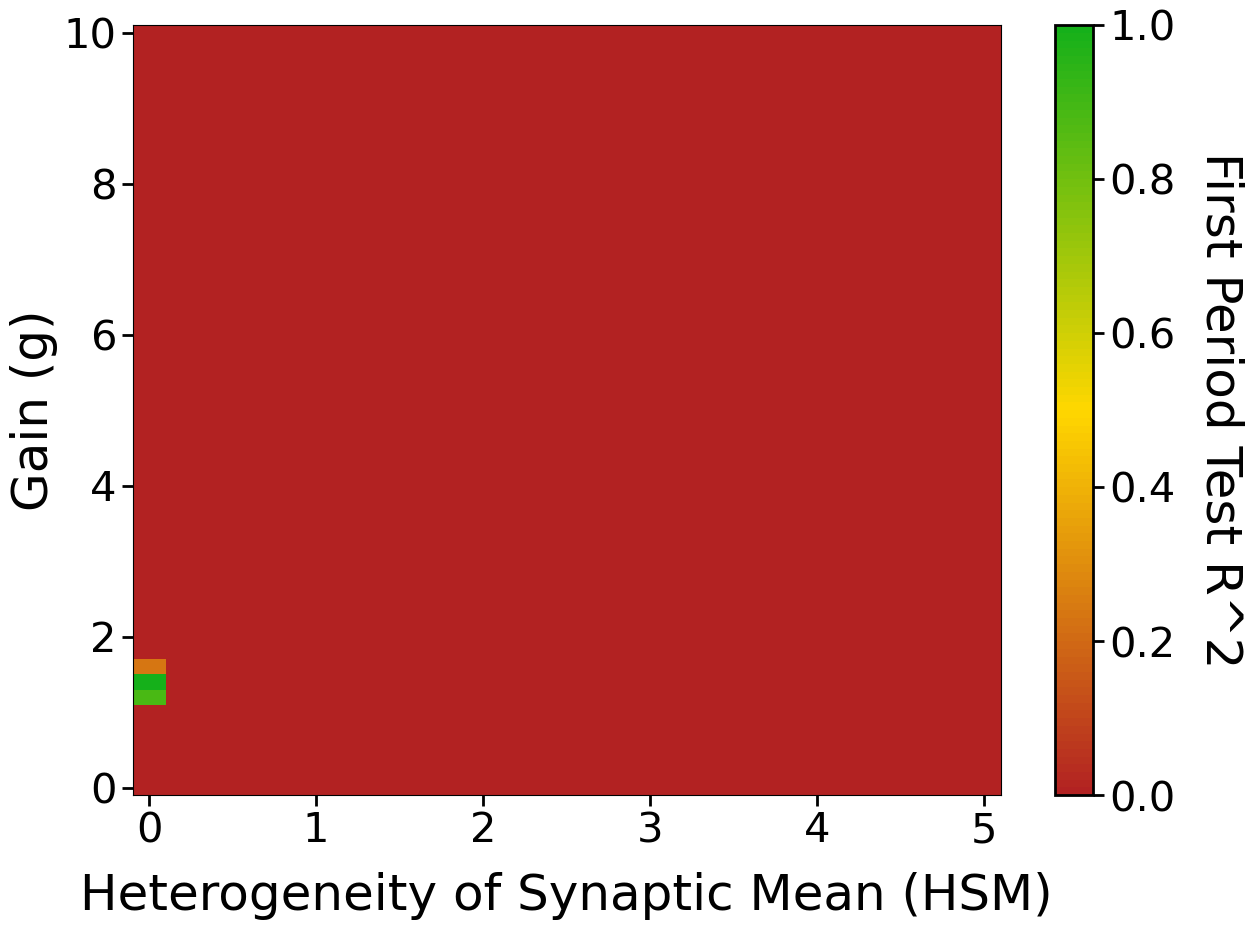


✓ Saved heatmap to: C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\ALL trials performance plot zoomed in HSM 0-0.1\Zoomed_in_W_first_period_Rsquared_testing_Heatmap_Gain_MSH_2026-03-23_13-54-11.png


In [13]:
# ============================================================================
# CREATE HEATMAP for multiple trial from TR1
# ============================================================================

from matplotlib.ticker import MaxNLocator

plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 36
plt.rcParams['xtick.labelsize'] = 30
plt.rcParams['ytick.labelsize'] = 30
plt.rcParams['legend.fontsize'] = 36
plt.rcParams['figure.titlesize'] = 30
plt.rcParams['legend.title_fontsize'] = 30

#tick size:
plt.rcParams['xtick.major.size'] = 8    # length of major ticks
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.major.width'] = 2  # width of major ticks
plt.rcParams['ytick.major.width'] = 2


# Custom colormap
dark_red = "#8B0000"
white = "white"
dark_green = "#013220"

dark_red      = "#8B0000"
firebrick     = "#B22222"
crimson       = "#DC143C"
indian_red    = "#CD5C5C"
light_coral   = "#F08080"
salmon        = "#FA8072"
tomato        = "#FF6347"
red           = "#FF0000"

gold          = "#FFD700"
dark_golden   = "#B8860B"
lemon         = "#FFF44F"

dark_orange     = "#FF8C00"
burnt_orange    = "#CC5500"
chocolate       = "#D2691E"
sienna          = "#A0522D"
coral           = "#FF7F50"
orange_red      = "#FF4500"
orange          = "#FFA500"


dark_green    = "#013220"
forest_green  = "#228B22"
sea_green     = "#2E8B57"
olive         = "#808000"
olive_drab    = "#6B8E23"
lime_green    = "#32CD32"
lime          = "#00FF00"
light_green   = "#90EE90"

####################CHANGING COLORS#############################
colors = [firebrick, gold, "xkcd:green"]  # for test after training
colors_averages = [red, lemon, dark_green] #for during training performance plot

n_bins = 100
cmap_name = 'custom_seismic'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

n_bins = 100
cmap_name = 'custom_seismic'
cm_averages = LinearSegmentedColormap.from_list(cmap_name, colors_averages, N=n_bins)

#cm = 'summer'

# Create DataFrame
df = pd.DataFrame({
    'G': gains,
    'W': weights_seeds,
    'I': init_seeds,
    'HSM': HSMs,
    'Rsquareds': Rsquareds
})

# Remove any NaN values
df = df[~np.isnan(df['Rsquareds'])]

# print(f"\nDataFrame shape: {df.shape}")
# print(f"First few rows:")
# print(df.head(10))

# Average over W (seeds) for each (G, HSM) combination
df_mean = df.groupby(['G', 'W', 'HSM', 'I'], as_index=False)['Rsquareds'].mean()

# Create pivot table for heatmap
heatmap_data = df_mean.pivot_table(index='G', columns='HSM', values='Rsquareds', aggfunc='mean')

# print(f"\nHeatmap data shape: {heatmap_data.shape}")
# print(f"Heatmap data:")
# print(heatmap_data)


# for if you do not want to compare between 1000N and 3000N
GLOBAL_VMIN = df_mean['Rsquareds'].min()
GLOBAL_VMAX = df_mean['Rsquareds'].max()

print(GLOBAL_VMAX, GLOBAL_VMIN)

# Create heatmap
plt.figure(figsize=(14, 10))

# Use pcolormesh for heatmap
im = plt.pcolormesh(
    heatmap_data.columns, 
    heatmap_data.index, 
    heatmap_data.values,
    shading='auto', 
    cmap=cm, 
    vmin=0.0,
    vmax=1.0
)

#for average during training
#Use pcolormesh for heatmap
# im = plt.pcolormesh(
#     heatmap_data.columns, 
#     heatmap_data.index, 
#     heatmap_data.values,
#     shading='auto', 
#     cmap=cm_averages, 
#     vmin=0, 
#     vmax=1.00
# )



# Add colorbar
cbar = plt.colorbar(im, label='First Period Test R^2')
# cbar = plt.colorbar(im, label='First Period Training R^2')

#cbar = plt.colorbar(im, label='Average Performance Testing R^2')
#cbar = plt.colorbar(im, label='Average Performance Training R^2')

cbar.set_label('First Period Test R^2', rotation=270, labelpad=50)

# # Add values as text on heatmap (optional)
# for i, gain_val in enumerate(heatmap_data.index):
#     for j, HSM_val in enumerate(heatmap_data.columns):
#         value = heatmap_data.iloc[i, j]
#         if value < 0.01:
#             if not np.isnan(value):
#                 plt.text(HSM_val, gain_val, f'', 
#                         ha='center', va='center', fontsize=8, 
#                         color='black',
#                         rotation=270)

#         else:             
#             # value = heatmap_data.iloc[i, j]
#             if not np.isnan(value):
#                 plt.text(HSM_val, gain_val, f'{value:.2f}', 
#                         ha='center', va='center', fontsize=10, 
#                         color='white',
#                         rotation=270)
#                         # color='white' if value > heatmap_data.values.mean() else 'black')



plt.xlabel('Heterogeneity of Synaptic Mean (HSM)', labelpad=15)
plt.ylabel('Gain (g)')
#plt.title('First Period Test R^2: Gain vs HSM')
#plt.title('First Period Training R^2: Gain vs HSM')

#plt.title('Average R^2 testing: Gain vs HSM')
#plt.title('Average R^2 training: Gain vs HSM')



# Save figure
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
filename = f"Zoomed_in_W_first_period_Rsquared_testing_Heatmap_Gain_HSM_{timestamp}.png"
#filename = f"First_period_Rsquared_training_Heatmap_Gain_HSM_{timestamp}.png"

#filename = f"Averages_performance_after_training_Heatmap_Gain_HSM_{timestamp}.png"
#filename = f"Averages_performance_during_training_Heatmap_Gain_HSM_{timestamp}.png"



#testing
# filepath = os.path.join(
#     r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\ALL trials performance plot intended W matrix or HSM",
#     filename
# )

#for zoomed in HSM
filepath = os.path.join(
    r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\ALL trials performance plot zoomed in HSM 0-0.1",
    filename
)

# filepath = os.path.join(
#     r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM averages during training heatmap performance",
#     filename
# )

# filepath = os.path.join(
#     r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM averages after training heatmap performance",
#     filename
# )


#for increasing the width of the plot edge line
# ax = plt.gca()
# ax.tick_params(axis='x', rotation=300)


for spine in ax.spines.values():
    spine.set_linewidth(2)

#for increasing the width of the edge line of the colour bar
cbar.outline.set_linewidth(2)

ax.xaxis.set_major_locator(MaxNLocator(nbins=11))
ax.yaxis.set_major_locator(MaxNLocator(nbins=11))


plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved heatmap to: {filepath}")



<>:73: SyntaxWarning: invalid escape sequence '\s'
<>:73: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24176\1938998021.py:73: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label('standard deviation ($\sigma$) of Rsquareds', rotation=270, labelpad=20)


7.720635916211923 0.0


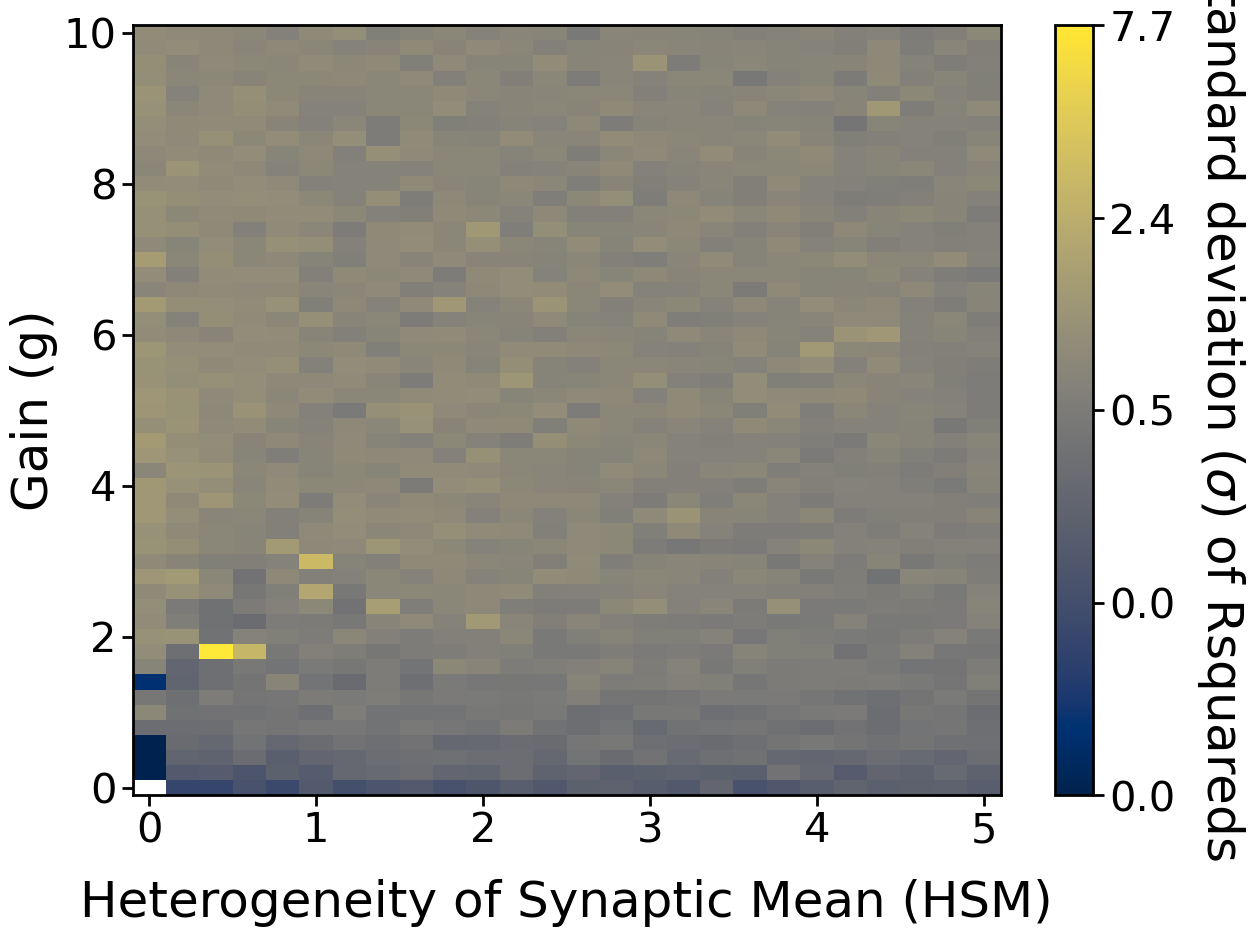

In [15]:
#Std heatmap

plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 36
plt.rcParams['xtick.labelsize'] = 30
plt.rcParams['ytick.labelsize'] = 30
plt.rcParams['legend.fontsize'] = 36
plt.rcParams['figure.titlesize'] = 30
plt.rcParams['legend.title_fontsize'] = 30

#tick size:
plt.rcParams['xtick.major.size'] = 8    # length of major ticks
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.major.width'] = 2  # width of major ticks
plt.rcParams['ytick.major.width'] = 2



# Create DataFrame
df = pd.DataFrame({
    'G': gains,
    'W': weights_seeds,
    'I': init_seeds,
    'HSM': HSMs,
    'Rsquareds': Rsquareds
})



# Average over W and I for each (G, HSM) combination
# (If you want to ignore W and I completely, comment the line below and uncomment the next one)
#df_mean = df.groupby(['G', 'HSM'], as_index=False)['L'].mean()
df_mean = df.groupby(['G', 'W', 'I', 'HSM'], as_index=False)['Rsquareds'].mean()
df_std = df_mean.groupby(['G', 'HSM'], as_index=False)['Rsquareds'].std()


heatmap_data = df_std.pivot_table(index='G', columns='HSM', values='Rsquareds', aggfunc='mean')


# Set the (G=0, HSM=0) cell to NaN → will render as white
if 0 in heatmap_data.index and 0 in heatmap_data.columns:
    heatmap_data.loc[0, 0] = np.nan


# for if you do not want to compare between 1000N and 3000N
GLOBAL_VMIN = df_std['Rsquareds'].min()
GLOBAL_VMAX = df_std['Rsquareds'].max()

print(GLOBAL_VMAX, GLOBAL_VMIN)

plt.figure(figsize=(14,10))

# Use GLOBAL vmin/vmax instead of data-specific min/max
norm = PowerNorm(
    gamma=0.25,
    vmin=GLOBAL_VMIN,  # Changed
    vmax=GLOBAL_VMAX   # Changed
)

cmap = plt.get_cmap('cividis').copy()
cmap.set_bad(color='white')

mesh = plt.pcolormesh(
    heatmap_data.columns,
    heatmap_data.index,
    heatmap_data.values,
    shading='auto',
    cmap=cmap,
    norm=norm
)

cbar = plt.colorbar(mesh)
cbar.set_label('standard deviation ($\sigma$) of Rsquareds', rotation=270, labelpad=20)
cbar.ax.yaxis.set_label_coords(5.0, 0.5)  # Adjust position if needed


cbar.ax.minorticks_off()

n_ticks = 5  
tick_positions = np.linspace(0, 1, n_ticks)

# Use GLOBAL values for tick calculation
data_min = GLOBAL_VMIN  # Changed
data_max = GLOBAL_VMAX  # Changed
gamma = 0.25
tick_values = data_min + (data_max - data_min) * (tick_positions ** (1/gamma))

rounded_labels = [f"{v:.01f}" for v in tick_values]

cbar.set_ticks(tick_values)
cbar.set_ticklabels(rounded_labels)



# plt.pcolormesh(heatmap_data.columns, heatmap_data.index, heatmap_data.values,
#                shading='auto', cmap='inferno')
# plt.colorbar(label='$\sigma$ of PR')
plt.xlabel('Heterogeneity of Synaptic Mean (HSM)', labelpad = 20)
plt.ylabel('Gain (g)')
# plt.title('Uncertainty of PR')
# plt.title('Heatmap of MLEs vs HSMs per Gains')


#for increasing the width of the plot edge line
# ax = plt.gca()
# ax.tick_params(axis='x', rotation=300)


#for increasing the width of the plot edge line
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)

#for increasing the width of the edge line of the colour bar
cbar.outline.set_linewidth(2)

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")
filename = f"LLE_1000N_0.2s_shortened_uncertainty_{timestamp}.png"
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\ALL trials performance plot zoomed in HSM 0-0.1", filename)
plt.savefig(filepath, dpi=300)

plt.show()

In [ ]:
# FIX: missing comma after 'I': init_seeds in the dict literal below --
# this was a SyntaxError (Python parses adjacent string/dict-value
# expressions without a comma between them as invalid). Added.
# ============================================================================
# CREATE HEATMAP for single trial
# ============================================================================

plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['legend.title_fontsize'] = 14

# Custom colormap
dark_red = "#8B0000"
white = "white"
dark_green = "#013220"

dark_red      = "#8B0000"
firebrick     = "#B22222"
crimson       = "#DC143C"
indian_red    = "#CD5C5C"
light_coral   = "#F08080"
salmon        = "#FA8072"
tomato        = "#FF6347"
red           = "#FF0000"

gold          = "#FFD700"
dark_golden   = "#B8860B"
lemon         = "#FFF44F"

dark_orange     = "#FF8C00"
burnt_orange    = "#CC5500"
chocolate       = "#D2691E"
sienna          = "#A0522D"
coral           = "#FF7F50"
orange_red      = "#FF4500"
orange          = "#FFA500"


dark_green    = "#013220"
forest_green  = "#228B22"
sea_green     = "#2E8B57"
olive         = "#808000"
olive_drab    = "#6B8E23"
lime_green    = "#32CD32"
lime          = "#00FF00"
light_green   = "#90EE90"

####################CHANGING COLORS#############################
colors = [firebrick, gold, "xkcd:green"]  # for test after training
colors_averages = [red, lemon, dark_green] #for during training performance plot

n_bins = 100
cmap_name = 'custom_seismic'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

n_bins = 100
cmap_name = 'custom_seismic'
cm_averages = LinearSegmentedColormap.from_list(cmap_name, colors_averages, N=n_bins)

#cm = 'summer'

# Create DataFrame
df = pd.DataFrame({
    'G': gains,
    'W': weights_seeds,
    'I': init_seeds,
    'HSM': HSMs,
    'Rsquareds': Rsquareds
})

# Remove any NaN values
df = df[~np.isnan(df['Rsquareds'])]

# print(f"\nDataFrame shape: {df.shape}")
# print(f"First few rows:")
# print(df.head(10))

# Average over W (seeds) for each (G, HSM) combination
df_mean = df.groupby(['G', 'HSM'], as_index=False)['Rsquareds'].mean()

# print(f"\nGrouped data shape: {df_mean.shape}")
# print(f"Grouped data:")
# print(df_mean)

# Create pivot table for heatmap
heatmap_data = df_mean.pivot_table(index='G', columns='HSM', values='Rsquareds', aggfunc='mean')

# print(f"\nHeatmap data shape: {heatmap_data.shape}")
# print(f"Heatmap data:")
# print(heatmap_data)

# Create heatmap
plt.figure(figsize=(8, 6))

# Use pcolormesh for heatmap
# im = plt.pcolormesh(heatmap_data.columns, heatmap_data.index, heatmap_data.values,
#                     shading='auto', cmap=cm, vmin=heatmap_data.values.min(), 
#                     vmax=heatmap_data.values.max())

#for average during training
#Use pcolormesh for heatmap
im = plt.pcolormesh(heatmap_data.columns, heatmap_data.index, heatmap_data.values,
                    shading='auto', cmap=cm_averages, vmin=0, 
                    vmax=1.00)



# Add colorbar
#cbar = plt.colorbar(im, label='First Period Test R^2')
# cbar = plt.colorbar(im, label='First Period Training R^2')

cbar = plt.colorbar(im, label='Average Performance Testing R^2')
#cbar = plt.colorbar(im, label='Average Performance Training R^2')



# Add values as text on heatmap (optional)
for i, gain_val in enumerate(heatmap_data.index):
    for j, HSM_val in enumerate(heatmap_data.columns):
        value = heatmap_data.iloc[i, j]
        if value < 0:
            if not np.isnan(value):
                plt.text(HSM_val, gain_val, f'', 
                        ha='center', va='center', fontsize=8, 
                        color='black')

        else:             
            # value = heatmap_data.iloc[i, j]
            if not np.isnan(value):
                plt.text(HSM_val, gain_val, f'{value:.2f}', 
                        ha='center', va='center', fontsize=8, 
                        color='white')
                        # color='white' if value > heatmap_data.values.mean() else 'black')



plt.xlabel('Heterogeneity of Synaptic Mean (HSM)')
plt.ylabel('Gain')
#plt.title('First Period Test R^2: Gain vs HSM')
#plt.title('First Period Training R^2: Gain vs HSM')

plt.title('Average R^2 testing: Gain vs HSM')
#plt.title('Average R^2 training: Gain vs HSM')



# Save figure
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
#filename = f"First_period_Rsquared_testing_Heatmap_Gain_HSM_{timestamp}.png"
#filename = f"First_period_Rsquared_training_Heatmap_Gain_HSM_{timestamp}.png"

filename = f"Averages_performance_after_training_Heatmap_Gain_HSM_{timestamp}.png"
#filename = f"Averages_performance_during_training_Heatmap_Gain_HSM_{timestamp}.png"



# #testing
# filepath = os.path.join(
#     r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM after training heatmap performance",
#     filename
# )

# filepath = os.path.join(
#     r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM averages during training heatmap performance",
#     filename
# )

filepath = os.path.join(
    r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM averages after training heatmap performance",
    filename
)

plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved heatmap to: {filepath}")



# J matrix Comparison Between Initial and After Training

In [230]:
# ============================================================================
# DIFFERENCES BEFORE AND AFTER TRAINING, INDIVIDUAL CASES
# ============================================================================

 


foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\VScode gainHSM zs vs sussillos target and Rsquareds during and after training"

#get all idx*.npz files
file_path = os.path.join(foldername, "idx013_gain1.2_HSM0.2_eta1.000_Dt0.2_20260201_193626.npz")


data = np.load(file_path)
J_initial = data['J_initial']
J_trained = data['J_trained']
w_out_initial = data['w_out_initial']
w_out_trained = data['w_out_trained']
gain = data['gain']
HSM = data['HSM']


# print(filepath, J_initial, J_initial.shape)
# print(filepath, J_trained, J_initial.shape)
# print(filepath, w_out_initial, w_out_initial.shape)
# print(filepath, w_out_trained, w_out_trained.shape)

mus_initial    = np.mean(J_initial, axis=1)
sigmas_initial = np.std(J_initial, axis=1)

mus_trained    = np.mean(J_trained, axis=1)
sigmas_trained = np.std(J_trained, axis=1)

mus_difference    = mus_trained - mus_initial
sigmas_difference = sigmas_trained - sigmas_initial
        
neuron_lin = np.linspace(1, 1000, 1000)

############## Plotting 
fig, axes = plt.subplots(3, 1, figsize=(24, 24))

# initial
axes[0].plot(neuron_lin, mus_initial, 'o', linewidth=2, label='Mean weight')
axes[0].set_xlabel('# of Neuron')
axes[0].set_ylabel('Mean ($\mu$)')
axes[0].set_title(f'mus initial with Gain={gain:.1f} and HSM={HSM:.1f}')
#axes[0].set_title(f'Training: gain={gain:.1f}, HSM={HSM:.1f} (η={eta:.3f}, Δt={Dt:.1f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# after training
axes[1].plot(neuron_lin, mus_trained, 'o', linewidth=2, label='Mean weight')
axes[1].set_xlabel('# of Neuron')
axes[1].set_ylabel('Mean ($\mu$)')
axes[1].set_title(f'mus trained with Gain={gain:.1f} and HSM={HSM:.1f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Difference
axes[2].plot(neuron_lin, mus_difference, 'k-', linewidth=2, label='Target')
axes[2].set_xlabel('# of Neuron')
axes[2].set_ylabel('shift in mean')
axes[1].set_title(f'mus difference')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

# Save figure
#fig_filename = f"idx{i:03d}_trajectories_gain{gain:.1f}_HSM{HSM:.1f}_{timestamp}.png"
fig_filename = f"Mus_before_after_training_Gain={gain:.1f}_HSM={HSM:.1f}.png"
#######################CHECK THIS FILE PATH############################
fig_filepath = os.path.join(
    r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gain HSM J matrix plots",
    fig_filename
)
plt.savefig(fig_filepath, dpi=300, bbox_inches='tight')
plt.close()


<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24944\4020510966.py:45: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_ylabel('Mean ($\mu$)')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24944\4020510966.py:54: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_ylabel('Mean ($\mu$)')


In [7]:
# ============================================================================
# DIFFERENCES BEFORE AND AFTER TRAINING w_out, ALL CASES
# ============================================================================
 
# === Global plot style ===
plt.rcParams.update({
    'axes.titlesize': 32,
    'axes.labelsize': 28,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'legend.fontsize': 20,
    'figure.titlesize': 32,
    'legend.title_fontsize': 28
})

foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\Zoomed HSM 0-0.1 performance plots\for differences in J plots"

files = glob.glob(os.path.join(foldername, "idx*.npz"))
files.sort(key=lambda f: int(os.path.basename(f)[3:6]))

for i, filepath in enumerate(files):

    data = np.load(filepath)
    J_initial       = data['J_initial']
    J_trained       = data['J_trained']
    w_out_initial   = data['w_out_initial']
    w_out_trained   = data['w_out_trained']
    gain            = data['gain']
    HSM             = data['HSM']

    print(J_initial.shape)

    mus_initial    = np.mean(w_out_initial, axis=1)
    sigmas_initial = np.std(w_out_initial, axis=1)
    mus_trained    = np.mean(w_out_trained, axis=1)
    sigmas_trained = np.std(w_out_trained, axis=1)
    mus_difference    = np.abs(mus_trained - mus_initial)
    sigmas_difference = np.abs(sigmas_trained - sigmas_initial)

    neuron_lin = np.linspace(1, 1000, 1000)

    fig, axes = plt.subplots(2, 1, figsize=(16, 12))

    # === Top plot ===
    axes[0].plot(neuron_lin, mus_initial, 'ro', linewidth=2, label='Initial $\mu_i$')
    axes[0].plot(neuron_lin, mus_trained, 'go', linewidth=2, label='After training $\mu_i$')
    axes[0].set_xlabel('# of Neuron')
    axes[0].set_ylabel('Mean per neuron $\mu_i$')
    #axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    axes[0].grid(True, alpha=0.3)
    #axes[0].set_ylim(-0.02, 0.02)

    # === Bottom plot ===
    axes[1].plot(neuron_lin, mus_difference, 'ko', linewidth=2, label='Difference')
    axes[1].set_xlabel('# of Neuron')
    axes[1].set_ylabel('absolute difference of $\mu_i$')
    axes[1].grid(True, alpha=0.3)
    #axes[1].yaxis.set_major_formatter(plt.FormatStrFormatter('%.4f'))
    #axes[1].set_ylim(0.0016, 0.0042)

    plt.tight_layout()
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    fig_filename = f"idx{i:03d}_w_out_difference_gain{gain:.1f}_HSM{HSM}_{timestamp}.png"
    fig_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\w_output matrix difference training thesis",
        fig_filename
    )
    plt.savefig(fig_filepath, dpi=300, bbox_inches='tight')
    plt.close()

print(f"Processed {len(files)} files")

<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20428\3449790257.py:45: SyntaxWarning: invalid escape sequence '\m'
  axes[0].plot(neuron_lin, mus_initial, 'ro', linewidth=2, label='Initial $\mu_i$')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20428\3449790257.py:46: SyntaxWarning: invalid escape sequence '\m'
  axes[0].plot(neuron_lin, mus_trained, 'go', linewidth=2, label='After training $\mu_i$')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20428\3449790257.py:48: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_ylabel('Mean per neuron $\mu_i$')
C:\Users\Lenovo\AppData\Local\

(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
Processed 10 files


In [ ]:
# FLAG (not fixed): this cell starts mid-block -- `filepath = r"..."` is
# indented as if it's inside a `for`/`if`/function body, but no such
# header exists in this cell, which is a SyntaxError ("unexpected
# indent"). It also references `i`, `gain`, `HSM`, `eta`, `Dt`, `timestamp`,
# `trainer`, `mean_mae`, `std_mae`, `RMSE_first_period`, `RMSEs_train`,
# `RMSEs_time_train`, `RMSEs_test`, `RMSEs_time_test` -- none of which are
# defined in this cell. This looks like the tail end of a loop body whose
# opening lines (and the code computing those RMSE variables) got cut off
# or live in a different cell. I didn't guess at reconstructing the missing
# header/loop, since that would mean inventing logic you didn't write --
# worth checking whether a cell above this one used to contain the rest.

  filepath = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\test\Periodic target zs vs target, RMSEs data"
    os.makedirs(filepath, exist_ok=True)
    
    filename = f"idx{i:03d}_gain{gain:.1f}_HSM{HSM:.1f}_eta{eta:.3f}_Dt{Dt:.1f}_{timestamp}.npz"
    full_path = os.path.join(filepath, filename)
    
    np.savez(
        full_path,
        J_initial=trainer.J_initial,
        w_out_initial=trainer.w_out_initial,
        J_trained=trainer.J_trained,
        w_out_trained=trainer.w_out_trained,
        z_out_training=train_zs['all_z_out'],
        z_out_test=test_zs['z_out'],
        running_time=running_time,
        test_time=test_time_arr,
        target_train=target_train,
        target_test=target_test,
        alpha=trainer.alpha,
        p=trainer.p,
        N=trainer.N,
        gain=gain,
        HSM=HSM,
        eta=eta,
        Dt=Dt,
        weights_seed=weights_seed,
        mean_test_mae=mean_mae,
        std_test_mae=std_mae,
        # Save ONLY first period test RMSE
        first_period_test_rmse=RMSE_first_period,
        # Also save all training RMSEs (for all periods)
        RMSEs_train=np.array(RMSEs_train),
        RMSEs_time_train=np.array(RMSEs_time_train),
        # Save all test RMSEs (for all periods) - for reference
        RMSEs_test_all_periods=np.array(RMSEs_test),
        RMSEs_time_test_all_periods=np.array(RMSEs_time_test)
    )
    




In [ ]:
# Test best configuration
start = time.time()

plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14    # x/y labels
plt.rcParams['xtick.labelsize'] = 12   # x ticks
plt.rcParams['ytick.labelsize'] = 12   # y ticks
plt.rcParams['legend.fontsize'] = 10   # legend text
plt.rcParams['figure.titlesize'] = 16  # suptitle (global title)
plt.rcParams['legend.title_fontsize'] = 14 # legend title

print(results['Etas'][0])

unique_Gains = np.unique(results['Gains'])
print(unique_Gains)

unique_HSMs = np.unique(results['HSMs'])
print(unique_HSMs)

#weights_seeds = np.unique(Weights_Seeds_sorted)

learn_start = 10 ##########################################CHECK THIS#####################################
dt = 0.1
learn_start_idx = int(learn_start / dt) 


# def __init__(self, N=1000, p=1.0, gain=1.5, HSM=0, 
#                  tau=10.0, dt=0.1, Dt=2.0, alpha=10.0, eta=0.1,
#                  weights_seed=1, initialisation_seed=1):

# Loop over all combinations of seeds and gains
for i, gain in enumerate(unique_Gains):

    for i_HSM, HSM in enumerate(unique_HSMs):
        plt.figure(figsize=(10,5))
    
            
        trainer = FC.FORCETrainer(
            N=1000,
            p=1.0,
            gain=gain,
            HSM=HSM,
            #HSM=HSMs_sorted[i],
            tau=10.0,
            dt=0.1,
            Dt=Dts_sorted[i],
            alpha=10,
            eta=Etas_sorted[i],
            weights_seed=Weights_Seeds_sorted[i],
            initialisation_seed=1
        )
        
        ############## Train
        train_time = 20
        running_time = np.arange(0, train_time, 0.1)
        target_train = FC.create_complex_target(running_time, 0.1)
        train_zs = trainer.train(target_train, running_time, verbose=True)
    
            
        target_shifted = np.full_like(target_train, np.nan)
        target_shifted[learn_start_idx:] = target_train[:-learn_start_idx]
    
        
        ############## Test
        after_training_time = 20
        test_time_arr = np.arange(0, after_training_time, 0.1)
        target_test = FC.create_complex_target(test_time_arr, 0.1)
        test_zs = trainer.test(target_test, test_time_arr, verbose=True)
            
        ###############saving it all
    
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    
        filepath = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\python code blocks for MPI4py\FORCE results\Complex periodic training and testing data" 
        
        # Create the folder if it doesn't exist
        os.makedirs(filepath, exist_ok=True)
        
        # Define filename
        #filename = f"force_best_params_alpha{best_params['alpha']}_Dt{best_params['Dt']}_eta{best_params['eta']}_{timestamp}.npz"
        filename = f"{i}force_best_params_Dt{Dts_sorted[i]:.3f}_eta{Etas_sorted[i]:.3f}_{timestamp}.npz"
        # Combine path and filename
        full_path = os.path.join(filepath, filename)
        
        # Save the data
        np.savez(
        full_path,
        J_initial=trainer.J_initial,
        w_out_initial=trainer.w_out_initial,
        J_trained=trainer.J_trained,
        w_out_trained=trainer.w_out_trained,
        z_out_training=train_zs['all_z_out'],
        z_out_test=test_zs['z_out'],
        running_time=running_time,
        test_time=test_time_arr,
        target_train=target_train,
        target_test=target_test,
        #alpha=best_params['alpha'],
        alpha=trainer.alpha,
        p=trainer.p,
        N=trainer.N,
        gain=gain,
        eta=Etas_sorted[i],
        Dt=Dts_sorted[i],
        # trial_test_maes = best_params['test_mae'],
        # trial_train_maes=best_params['train_mae'],
        mean_test_mae=mean_mae_sorted[i],
        std_test_mae=std_mae_sorted[i]
        )
        
        print(f"✓ Saved to: {full_path}")
    
        #plotting and saving plots of training and testing trajectories
    
        fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
        # Training
        axes[0].plot(running_time, target_shifted, 'k-', linewidth=2, label='Target')
        axes[0].plot(running_time, train_zs['all_z_out'], 'g--', linewidth=2, label='RNN output', alpha=1)
        # axes[0].set_xlim([0, 10000])
        axes[0].set_xlabel('Time (ms)')
        axes[0].set_ylabel('Signal')
        #axes[0].set_title(f'Training (alpha={best_params["alpha"]:.3f}, eta={best_params["eta"]:.3f}, Dt={best_params["Dt"]:.1f})')
        axes[0].set_title(f'Training with gain={gain} (eta={Etas_sorted[i]:.3f}, Dt={Dts_sorted[i]:.3f})')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Testing
        axes[1].plot(test_time_arr, target_test, 'k-', linewidth=2, label='Target')
        axes[1].plot(test_time_arr, test_zs['z_out'], 'r--', linewidth=2, label='RNN output', alpha=1)
        axes[1].set_xlabel('Time (ms)')
        axes[1].set_ylabel('Signal')
        axes[1].set_title(f'Testing (MAE: {mean_mae_sorted[i,0]:.6f})')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")
        
        # Save figure
        filename = f"{i}, gain={gain}, time={timestamp}.png"
        
        #change path depending on 10% connectivity or not
        filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\Optimized_zs_vs_target_during_after_FORCE", filename)
        #plt.subplots_adjust(right=0.8) #leaving space for legend
        plt.savefig(filepath, dpi = 300)
        plt.show()
    
        #plottting rmse during and after training
    
            # Parameters
        dt = trainer.dt  # 0.1
        freq = 0.5
        T_period = (1/freq) * 1000  # 1000 because in ms
        steps_per_period = int(T_period / dt)
        total_time_steps = len(running_time)
        
        # Storage for RMSE
        RMSEs = []
        RMSEs_time = []
        
        # Calculate RMSE per period
        for idx in range(0, total_time_steps, steps_per_period):
            # Get data for this period
            time_per_period = running_time[idx:idx+steps_per_period]
            target_per_period = target_train[idx:idx+steps_per_period]
            z_per_period = train_zs['all_z_out'][idx:idx+steps_per_period]
            
            # Only calculate if we have a full period
            if len(z_per_period) == steps_per_period:
                end_time_step = time_per_period[-1]
                
                # RMSE formula: sqrt(mean(squared_errors))
                sum_SE = ((target_per_period - z_per_period)**2).sum()
                RMSE = np.sqrt(sum_SE / steps_per_period)
                
                RMSEs.append(RMSE)
                RMSEs_time.append(end_time_step)
        
        # Plot RMSE during training
        plt.figure(figsize=(10, 4))
        plt.plot(RMSEs_time, RMSEs, 'b-', linewidth=2, label='RMSE between Target and Z')
        plt.xlabel('Time (ms)', fontsize=12)
        plt.ylabel('RMSE', fontsize=12)
        plt.legend()
        plt.title(f'RMSE DURING training for gain={gain}: (eta={Etas_sorted[i]:.3f}, Dt={Dts_sorted[i]:.3f})')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")
        
        # Save figure
        filename = f"{i}RMSE_z_vs_target_during_FORCE, gain{gain}, {timestamp}.png"
        
        #change path depending on 10% connectivity or not
        filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\RMSE DURING FORCE", filename)
        #plt.subplots_adjust(right=0.8) #leaving space for legend
        plt.savefig(filepath, dpi = 300)
        
        plt.show()
    
    
    
    
        # Parameters
        dt = trainer.dt  # 0.1
        freq = 0.5
        T_period = (1/freq) * 1000  # 1000 because in ms
        steps_per_period = int(T_period / dt)
        total_time_steps = len(test_time_arr)
        
        # Storage for RMSE
        RMSEs = []
        RMSEs_time = []
        
        # Calculate RMSE per period
        for idx in range(0, total_time_steps, steps_per_period):
            # Get data for this period
            time_per_period = running_time[idx:idx+steps_per_period]
            target_per_period = target_train[idx:idx+steps_per_period]
            z_per_period = test_zs['z_out'][idx:idx+steps_per_period]
            
            # Only calculate if we have a full period
            if len(z_per_period) == steps_per_period:
                end_time_step = time_per_period[-1]
                
                # RMSE formula: sqrt(mean(squared_errors))
                sum_SE = ((target_per_period - z_per_period)**2).sum()
                RMSE = np.sqrt(sum_SE / steps_per_period)
                
                RMSEs.append(RMSE)
                RMSEs_time.append(end_time_step)
        
        # Plot RMSE during training
        plt.figure(figsize=(10, 4))
        plt.plot(RMSEs_time, RMSEs, 'b-', linewidth=2, label='RMSE between Target and Z')
        plt.xlabel('Time (ms)', fontsize=12)
        plt.ylabel('RMSE', fontsize=12)
        plt.legend()
        plt.title(f'{i}RMSE AFTER training for gain = {gain}:(eta={Etas_sorted[i]:.3f}, Dt={Dts_sorted[i]:.3f}')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")
        
        # Save figure
        filename = f"{i}RMSE_z_vs_target_after_FORCE, gain{gain}, {timestamp}.png"
        
        #change path depending on 10% connectivity or not
        filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\RMSE AFTER FORCE", filename)
        #plt.subplots_adjust(right=0.8) #leaving space for legend
        plt.savefig(filepath, dpi = 300)
        
        plt.show()


end = time.time()
print(f"Duration of running: {end - start: .3f} seconds")

In [226]:
#to access .npz files:import numpy as np

# Load the file
data = np.load('C:python code blocks for MPI4py\FORCE results\Complex periodic training and testing data\2force_best_params_Dt19.010_eta0.624_20260122_174845.npz')

# Access individual values
N = data['N']
gain = data['gain']
eta = data['eta']
alpha = data['alpha']
Dt = data['Dt']
tau = data['tau']

print(f"N = {N}")
print(f"gain = {gain}")
print(f"eta = {eta}")
print(f"alpha = {alpha}")
print(f"Dt = {Dt}")
print(f"tau = {tau}")

<>:4: SyntaxWarning: invalid escape sequence '\F'
<>:4: SyntaxWarning: invalid escape sequence '\F'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18616\2832940521.py:4: SyntaxWarning: invalid escape sequence '\F'
  data = np.load('C:python code blocks for MPI4py\FORCE results\Complex periodic training and testing data\2force_best_params_Dt19.010_eta0.624_20260122_174845.npz')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18616\2832940521.py:4: SyntaxWarning: invalid escape sequence '\F'
  data = np.load('C:python code blocks for MPI4py\FORCE results\Complex periodic training and testing data\2force_best_params_Dt19.010_eta0.624_20260122_174845.npz')


OSError: [Errno 22] Invalid argument: 'C:python code blocks for MPI4py\\FORCE results\\Complex periodic training and testing data\x02force_best_params_Dt19.010_eta0.624_20260122_174845.npz'

### plotting zs vs target during and after training and RMSE during and after training

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Training
axes[0].plot(running_time, target_train, 'k-', linewidth=2, label='Target')
axes[0].plot(running_time, train_zs['all_z_out'], 'g--', linewidth=2, label='RNN output', alpha=1)
# axes[0].set_xlim([0, 10000])
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Signal')
#axes[0].set_title(f'Training (alpha={best_params["alpha"]:.3f}, eta={best_params["eta"]:.3f}, Dt={best_params["Dt"]:.1f})')
axes[0].set_title(f'Training with gain={gain} (eta={best_params["eta"]:.3f}, Dt={Dt})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Testing
axes[1].plot(test_time_arr, target_test, 'k-', linewidth=2, label='Target')
axes[1].plot(test_time_arr, test_zs['z_out'], 'r--', linewidth=2, label='RNN output', alpha=1)
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Signal')
axes[1].set_title(f'Testing (MAE: {test_zs["mae"]:.6f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")

# Save figure
filename = f"z_vs_target_during_and_after_FORCE{timestamp}.png"

#change path depending on 10% connectivity or not
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\zs_vs_target_during_FORCE", filename)
#plt.subplots_adjust(right=0.8) #leaving space for legend
plt.savefig(filepath, dpi = 300)
plt.show()


In [ ]:

#RMSE during training

# Parameters
dt = trainer.dt  # 0.1
freq = 0.5
T_period = (1/freq) * 1000  # 1000 because in ms
steps_per_period = int(T_period / dt)
total_time_steps = len(running_time)

# Storage for RMSE
RMSEs = []
RMSEs_time = []

# Calculate RMSE per period
for i in range(0, total_time_steps, steps_per_period):
    # Get data for this period
    time_per_period = running_time[i:i+steps_per_period]
    target_per_period = target_train[i:i+steps_per_period]
    z_per_period = train_results['all_z_out'][i:i+steps_per_period]
    
    # Only calculate if we have a full period
    if len(z_per_period) == steps_per_period:
        end_time_step = time_per_period[-1]
        
        # RMSE formula: sqrt(mean(squared_errors))
        sum_SE = ((target_per_period - z_per_period)**2).sum()
        RMSE = np.sqrt(sum_SE / steps_per_period)
        
        RMSEs.append(RMSE)
        RMSEs_time.append(end_time_step)

# Plot RMSE during training
plt.figure(figsize=(10, 4))
plt.plot(RMSEs_time, RMSEs, 'b-', linewidth=2, label='RMSE between Target and Z')
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.title(f'RMSE DURING training for gain={gain}: (eta={trainer.eta:.3f}, alpha={trainer.alpha:.1f}, Dt={trainer.Dt:.1f}, tau={trainer.tau:.1f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")

# Save figure
filename = f"RMSE_z_vs_target_during_FORCE, gain{gain}, {timestamp}.png"

#change path depending on 10% connectivity or not
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\RMSE DURING FORCE", filename)
#plt.subplots_adjust(right=0.8) #leaving space for legend
plt.savefig(filepath, dpi = 300)

plt.show()

In [ ]:

#RMSE after training

# Parameters
dt = trainer.dt  # 0.1
freq = 0.5
T_period = (1/freq) * 1000  # 1000 because in ms
steps_per_period = int(T_period / dt)
total_time_steps = len(running_time)

# Storage for RMSE
RMSEs = []
RMSEs_time = []

# Calculate RMSE per period
for i in range(0, total_time_steps, steps_per_period):
    # Get data for this period
    time_per_period = running_time[i:i+steps_per_period]
    target_per_period = target_train[i:i+steps_per_period]
    z_per_period = test_results['z_out'][i:i+steps_per_period]
    
    # Only calculate if we have a full period
    if len(z_per_period) == steps_per_period:
        end_time_step = time_per_period[-1]
        
        # RMSE formula: sqrt(mean(squared_errors))
        sum_SE = ((target_per_period - z_per_period)**2).sum()
        RMSE = np.sqrt(sum_SE / steps_per_period)
        
        RMSEs.append(RMSE)
        RMSEs_time.append(end_time_step)

# Plot RMSE during training
plt.figure(figsize=(10, 4))
plt.plot(RMSEs_time, RMSEs, 'b-', linewidth=2, label='RMSE between Target and Z')
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.title(f'RMSE AFTER training for gain = {gain}:(eta={trainer.eta:.3f}, alpha={trainer.alpha:.1f}, Dt={trainer.Dt:.1f}, tau={trainer.tau:.1f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")

# Save figure
filename = f"RMSE_z_vs_target_after_FORCE, gain{gain}, {timestamp}.png"

#change path depending on 10% connectivity or not
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\RMSE AFTER FORCE", filename)
#plt.subplots_adjust(right=0.8) #leaving space for legend
plt.savefig(filepath, dpi = 300)

plt.show()


## Analyses of J before and after training

In [ ]:
foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\test\Periodic target zs vs target, RMSEs data"

#get all idx*.npz files
files = glob.glob(os.path.join(foldername, "idx*.npz"))

#sorting them by idx number, if necessary
files.sort(key=lambda f: int(os.path.basename(f)[3:6]))

for filepath in files:
    for i in range(66):
    
        data = np.load(filepath)
        J_initial = data['J_initial']
        J_trained = data['J_trained']
        w_out_initial = data['w_out_initial']
        w_out_trained = data['w_out_trained']
    
        # print(filepath, J_initial, J_initial.shape)
        # print(filepath, J_trained, J_initial.shape)
        # print(filepath, w_out_initial, w_out_initial.shape)
        # print(filepath, w_out_trained, w_out_trained.shape)
    
        mus_initial    = np.mean(J_initial, axis=1)
        sigmas_initial = np.std(J_initial, axis=1)
        
        mus_trained    = np.mean(J_trained, axis=1)
        sigmas_trained = np.std(J_trained, axis=1)
        
        mus_difference    = mus_trained - mus_initial
        sigmas_difference = sigmas_trained - sigmas_initial
                
        neuron_lin = np.linspace(1, 1000, 1000)
        
        ############## Plotting 
        fig, axes = plt.subplots(3, 1, figsize=(12, 8))
        
        # initial
        axes[0].plot(neuron_lin, mus_initial, 'o', linewidth=2, label='Target')
        axes[0].set_xlabel('# of Neuron')
        axes[0].set_ylabel('Mean (mu)')
        axes[0].set_title(f'mus initial')
        #axes[0].set_title(f'Training: gain={gain:.1f}, HSM={HSM:.1f} (η={eta:.3f}, Δt={Dt:.1f})')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # after training
        axes[1].plot(neuron_lin, mus_trained, 'o', linewidth=2, label='Target')
        axes[1].set_xlabel('# of Neuron')
        axes[1].set_ylabel('Mean (mu)')
        axes[1].set_title(f'mus trained')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
        # Difference
        axes[2].plot(neuron_lin, mus_difference, 'k-', linewidth=2, label='Target')
        axes[2].set_xlabel('# of Neuron')
        axes[2].set_ylabel('shift in mean')
        axes[1].set_title(f'mus difference')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Save figure
        #fig_filename = f"idx{i:03d}_trajectories_gain{gain:.1f}_HSM{HSM:.1f}_{timestamp}.png"
        fig_filename = f"idx{i:03d}.png"
        #######################CHECK THIS FILE PATH############################
        fig_filepath = os.path.join(
            r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gain HSM J matrix plots",
            fig_filename
        )
        plt.savefig(fig_filepath, dpi=300, bbox_inches='tight')
        plt.close()
        
    

print(f"Loaded {len(rmses)} configurations")
print(f"Gains: {np.unique(gains)}")
print(f"HSMs: {np.unique(HSMs)}")

In [ ]:
J_initial = trainer.J_initial
print(J_initial.shape)
w_out_initial = trainer.w_out_initial
print(w_out_initial.shape)

In [ ]:
#plt.hist(masked_Ws, bins = 1000, alpha = 0.7, edgecolor = "black")

mus_neurons = []
sigmas_neurons = []
for i in tqdm(range(0,1000,10)):
    mean_neuron = np.mean(J_trained[i,:])
    std_neuron = np.std(J_trained[i,:])

    mus_neurons.append(mean_neuron)
    sigmas_neurons.append(std_neuron)
    
    plt.hist(J_trained[i,:].ravel(), bins = 100, alpha = 0.7, edgecolor = "tab:blue")#.ravel() flattens the 2D Ws[i,:,:] to an 1D array so it can plot all the values in the histogram
    plt.title(f"Presynaptic weights distribution to neuron {i} with mu {mean_neuron} and sigma {std_neuron}")
    plt.show()

mus_neurons = np.array(mus_neurons)
sigmas_neurons = np.array(sigmas_neurons)

In [ ]:
#plt.hist(masked_Ws, bins = 1000, alpha = 0.7, edgecolor = "black")

mus_neurons = []
sigmas_neurons = []
for i in tqdm(range(1000)):
    mean_neuron = np.mean(J_trained[i,:])
    std_neuron = np.std(J_trained[i,:])

    mus_neurons.append(mean_neuron)
    sigmas_neurons.append(std_neuron)
    
    # plt.hist(J[i,:].ravel(), bins = 100, alpha = 0.7, edgecolor = "tab:blue")#.ravel() flattens the 2D Ws[i,:,:] to an 1D array so it can plot all the values in the histogram
    # plt.title(f"Presynaptic weights distribution to neuron {i} with mu {mean_neuron} and sigma {std_neuron}")
    # plt.show()

mus_neurons = np.array(mus_neurons)
sigmas_neurons = np.array(sigmas_neurons)

In [ ]:
mus_neurons = np.array(mus_neurons)

mean_mus = np.mean(mus_neurons)
sigma_mus = np.std(mus_neurons)

plt.hist(mus_neurons.ravel(), bins = 100, alpha = 0.7, color = "tab:red", edgecolor = "tab:red");
plt.title(f"Presynaptic weights Means distribution to all neurons, with mean {mean_mus}, and sigma {sigma_mus}")

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")

# Save figure
filename = f"Mus_distribution_J_trained{timestamp}.png"

#change path depending on 10% connectivity or not
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\Distribution of mus for J_trained", filename)
#plt.subplots_adjust(right=0.8) #leaving space for legend
plt.savefig(filepath, dpi = 300)
plt.show()


In [ ]:
sigmas_neurons = np.array(sigmas_neurons)

mean_sigmas = np.mean(sigmas_neurons)
sigma_sigmas = np.std(sigmas_neurons)

plt.hist(sigmas_neurons.ravel(), bins = 100, alpha = 0.7, color = "black", edgecolor = "black");
plt.title(f"Presynaptic weights Sigmas distribution for all neurons, with mean {mean_sigmas}, and sigma {sigma_sigmas}")


timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")

# Save figure
filename = f"Sigmas_distribution_J_trained{timestamp}.png"

#change path depending on 10% connectivity or not
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\Distribution of sigmas for J_trained", filename)
#plt.subplots_adjust(right=0.8) #leaving space for legend
plt.savefig(filepath, dpi = 300)
plt.show()


# Execution cells for Hyperparameter Optimization for Different Targets **On Local Computer**

In [ ]:
#random search
start = time.time()

gain = 1.5

print("\n--- RANDOM SEARCH EXAMPLE ---")
param_ranges = {
    'eta': (0.01, 1),
    #'alpha': (1.0, 50.0),
    'Dt': (0.5, 20.0),
    #'tau': (0.1, 30.0)
}

random_results = FC.random_search(
    param_ranges,
    gain = gain,
    n_iterations=10,  # Try 20 random configurations
    n_trials=1, #number of seeds it will try, but I am only interested in one seed for now so one trial
    train_time=1000,
    test_time=100,
    verbose=True
)

print("\n" + "="*60)
print(f"TOP 5 CONFIGURATIONS for gain={gain}:")
print("="*60)
for i, result in enumerate(random_results[:5]):
    print(f"  eta={result['eta']:.4f}, Dt={result['Dt']:.4f}")
    #print(f"  eta={result['eta']:.4f}, Dt={result['Dt']:.4f}, alpha={result['alpha']:.4f}, tau={result['tau']:.4f} ")
    print(f"  Test MAE: {result['mean_test_mae']:.6f} ± {result['std_test_mae']:.6f}")
    print(f"  Train MAE: {result['mean_train_mae']:.6f}")


end = time.time()
print(f"Duration of running: {end - start: .3f} seconds")

In [ ]:
# Test best configuration
start = time.time()

print("\n" + "="*60)
print("TESTING BEST CONFIGURATION")
print("="*60)
best_params = random_results[0]

gain=1.5

trainer = FC.FORCETrainer(
    N=1000,
    p=1.0,
    gain=gain,
    tau=10.0,
    dt=0.1,
    #Dt = 20,
    Dt=best_params['Dt'],
    #alpha=best_params['alpha'],
    eta=best_params['eta'],
    weights_seed=1,
    initialisation_seed=1
)

# Train
train_time = 50000
running_time = np.arange(0, train_time, 0.1)
target_train = FC.create_complex_target(running_time, 0.1)
train_zs = trainer.train(target_train, running_time, verbose=True)

# Test
test_time_arr = np.arange(0, 10000, 0.1)
target_test = FC.create_complex_target(test_time_arr, 0.1)
test_zs = trainer.test(target_test, test_time_arr, verbose=True)


end = time.time()
print(f"Duration of running: {end - start: .3f} seconds")

In [180]:
#saving best params

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

filepath = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\python code blocks for MPI4py\FORCE results\Best params for specific targets" 

# Create the folder if it doesn't exist
os.makedirs(filepath, exist_ok=True)



# Define filename
#filename = f"force_best_params_alpha{best_params['alpha']}_Dt{best_params['Dt']}_eta{best_params['eta']}_{timestamp}.npz"
filename = f"force_best_params_Dt{best_params['Dt']:.3f}_eta{best_params['eta']:.3f}_{timestamp}.npz"
# Combine path and filename
full_path = os.path.join(filepath, filename)

best_params = random_results[0]

# Save the data
np.savez(
    full_path,
    J_initial=trainer.J_initial,
    w_out_initial=trainer.w_out_initial,
    J_trained=trainer.J_trained,
    w_out_trained=trainer.w_out_trained,
    z_out_training=train_zs['all_z_out'],
    z_out_test=test_zs['z_out'],
    running_time=running_time,
    test_time=test_time_arr,
    target_train=target_train,
    target_test=target_test,
    #alpha=best_params['alpha'],
    alpha=trainer.alpha,
    p=trainer.p,
    N=trainer.N,
    gain=gain,
    eta=best_params['eta'],
    Dt=best_params['Dt'],
    trial_test_maes = best_params['test_maes'], #I do not even need this because it prints already maus per trial and iteration in the output.log in TR1
    trial_train_maes=best_params['train_maes'],
    mean_test_mae=best_params['mean_test_mae'],
    std_test_mae=best_params['std_test_mae']
)

print(f"✓ Saved to: {full_path}")

✓ Saved to: C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\python code blocks for MPI4py\FORCE results\Best params for specific targets\force_best_params_Dt0.626_eta0.583_20260122_160455.npz


In [192]:
#to access .npz files:import numpy as np

# Load the file
data = np.load("python code blocks for MPI4py/FORCE results/Best params for specific targets/force_best_params_Dt0.626_eta0.583_20260122_160455.npz")

# Access individual values
N = data['N']
gain = data['gain']
eta = data['eta']
alpha = data['alpha']
Dt = data['Dt']
trial_test_maes = data['trial_test_maes']
trial_train_maes = data['trial_train_maes']

print(f"N = {N}")
print(f"gain = {gain}")
print(f"eta = {eta}")
print(f"alpha = {alpha}")
print(f"Dt = {Dt}")
print(f"trial_test_maes={trial_test_maes}")
print(f"trial_train_maes={trial_train_maes}")

N = 1000
gain = 1.5
eta = 0.3289678585253949
alpha = 10.0
Dt = 9.77006572242783
trial_test_maes=[0.82423466]
trial_train_maes=[0.44256195]


## plotting results

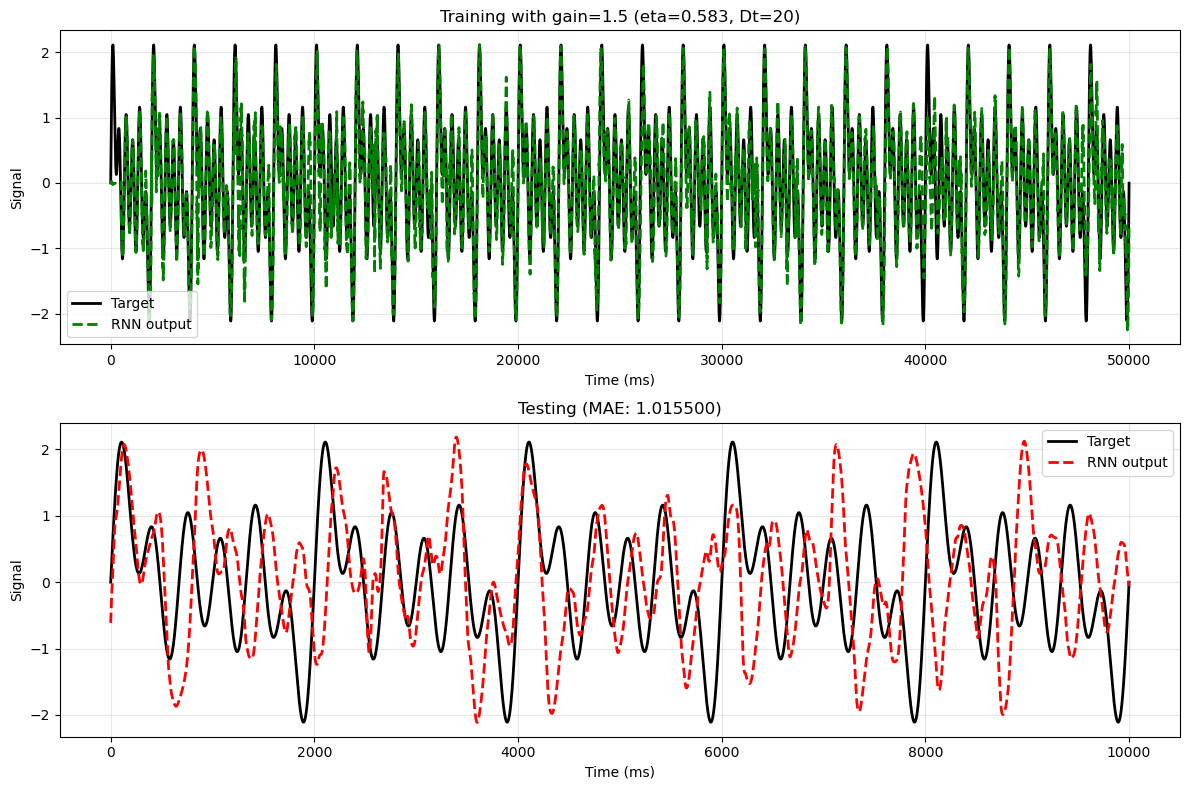

In [136]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
Dt=20
# Training
axes[0].plot(running_time, target_train, 'k-', linewidth=2, label='Target')
axes[0].plot(running_time, train_zs['all_z_out'], 'g--', linewidth=2, label='RNN output', alpha=1)
# axes[0].set_xlim([0, 10000])
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Signal')
#axes[0].set_title(f'Training (alpha={best_params["alpha"]:.3f}, eta={best_params["eta"]:.3f}, Dt={best_params["Dt"]:.1f})')
axes[0].set_title(f'Training with gain={gain} (eta={best_params["eta"]:.3f}, Dt={Dt})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Testing
axes[1].plot(test_time_arr, target_test, 'k-', linewidth=2, label='Target')
axes[1].plot(test_time_arr, test_zs['z_out'], 'r--', linewidth=2, label='RNN output', alpha=1)
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Signal')
axes[1].set_title(f'Testing (MAE: {test_zs["mae"]:.6f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")

# Save figure
filename = f"z_vs_target_during_and_after_FORCE{timestamp}.png"

#change path depending on 10% connectivity or not
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\zs_vs_target_during_FORCE", filename)
#plt.subplots_adjust(right=0.8) #leaving space for legend
plt.savefig(filepath, dpi = 300)
plt.show()

